# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 51     |  |
| :-------------|:-------------|
| Kimi Hekmat| 6534759 |
| Frank de Kogel| 6582737 |
| Student naam 3| Student Studienummer 3 |

In [29]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Frank', 'Kimi']

## Opdracht 1: Planning.

| Planning Groep: 51     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | 12:30 |
| Mijlpaal 2 | 16:30 |
| groep aanwezig 1| 13:30 |
| groep aanwezig 2| 16:15 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [51]
Bij onze kalibratieopstelling meten we enkel de afstand heen (er is geen afstand terug)
<img src="kalibratie_echo.jpeg" width="400">

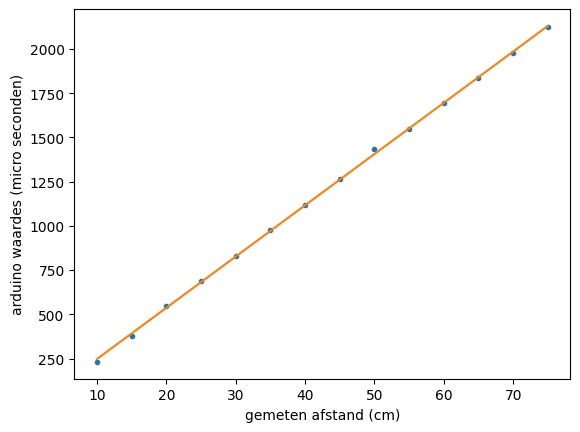

[ 28.97450549 -42.48791209]


In [31]:
# verwerk hier jullie kalibratiemetingen

fysiek = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]) # afstanden in centimeters (voorkant vericale platen)
arduino = np.array([231, 378, 549, 687, 830, 975, 1119, 1266, 1433, 1548, 1693, 1837, 1977, 2122]) # Meettijden in microseconden

def fit(x, a, b):
    return a*x + b

vals, covs = curve_fit(fit, fysiek, arduino)
xtest = np.linspace(np.min(fysiek), np.max(fysiek), 500)
ytest = fit(xtest, *vals)

plt.figure()
plt.plot(fysiek, arduino, '.', label = 'meetdata')
plt.plot(xtest, ytest, label = 'fit')
plt.xlabel('gemeten afstand (cm)')
plt.ylabel('arduino waardes (micro seconden)')
plt.show()

print(vals)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.6
1   0  30   0  20  41.1
2  40   0  30   0  39.9
3  30   0  20   0  40.3


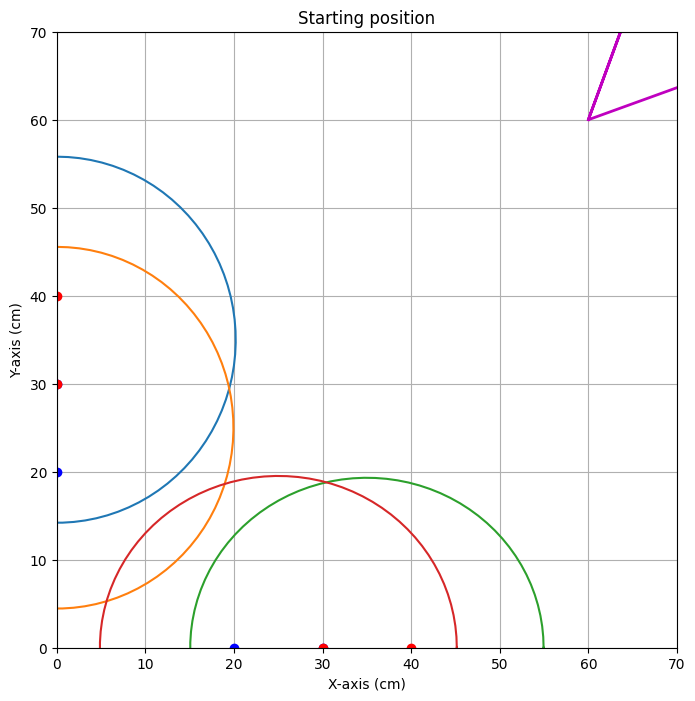


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.230


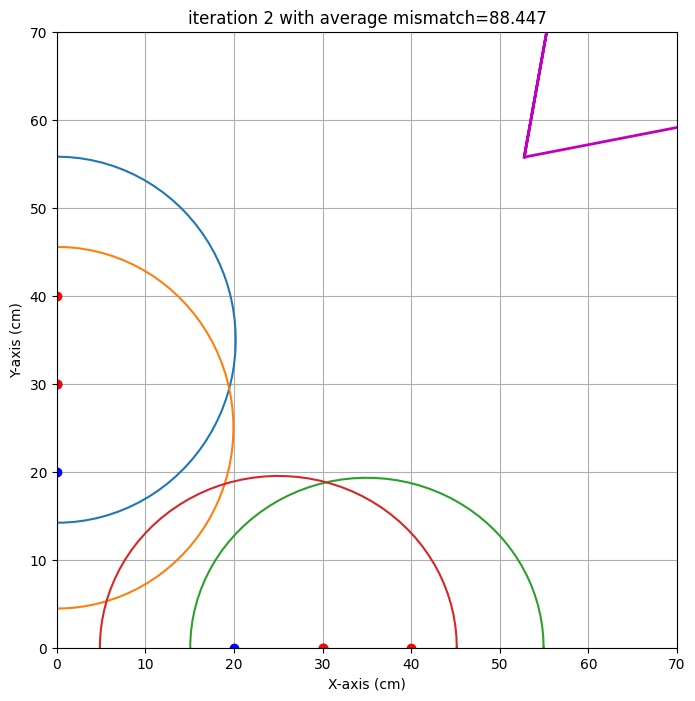

end iteration 2 with average mismatch=88.447


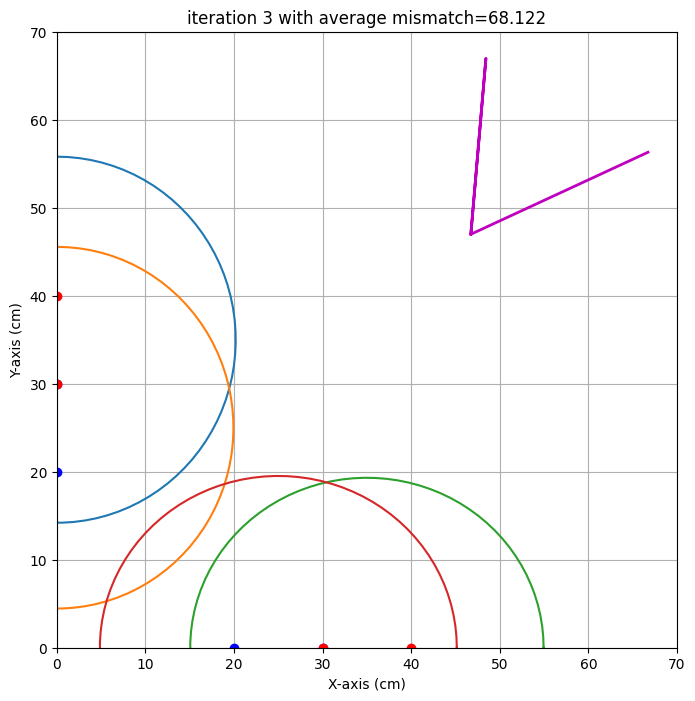

end iteration 3 with average mismatch=68.122


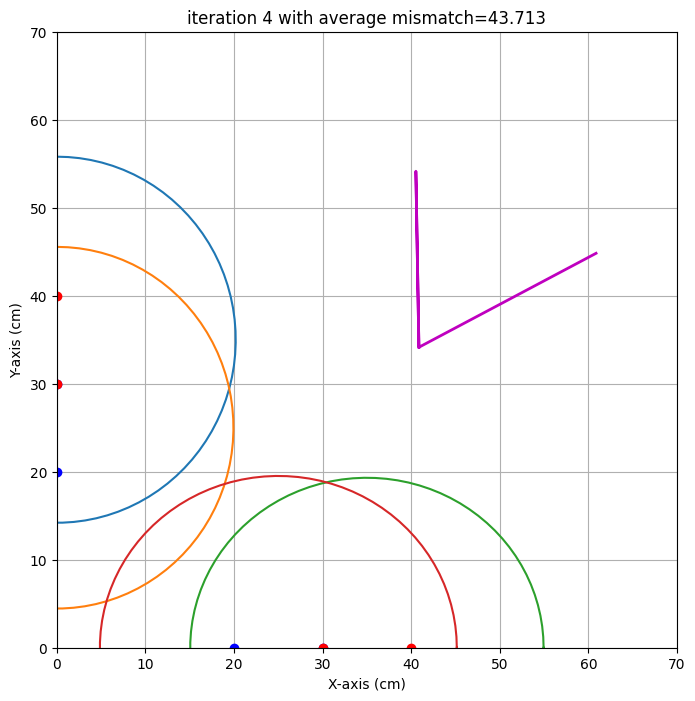

end iteration 4 with average mismatch=43.713


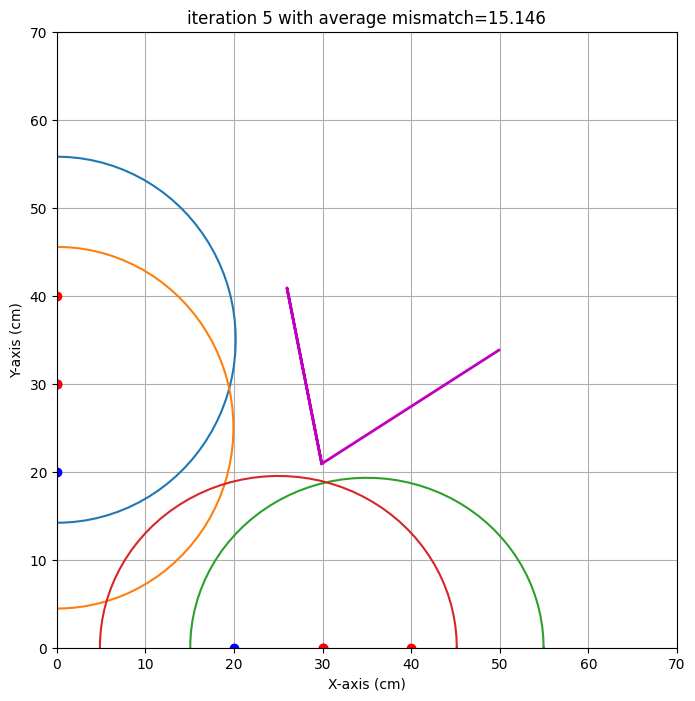

end iteration 5 with average mismatch=15.146


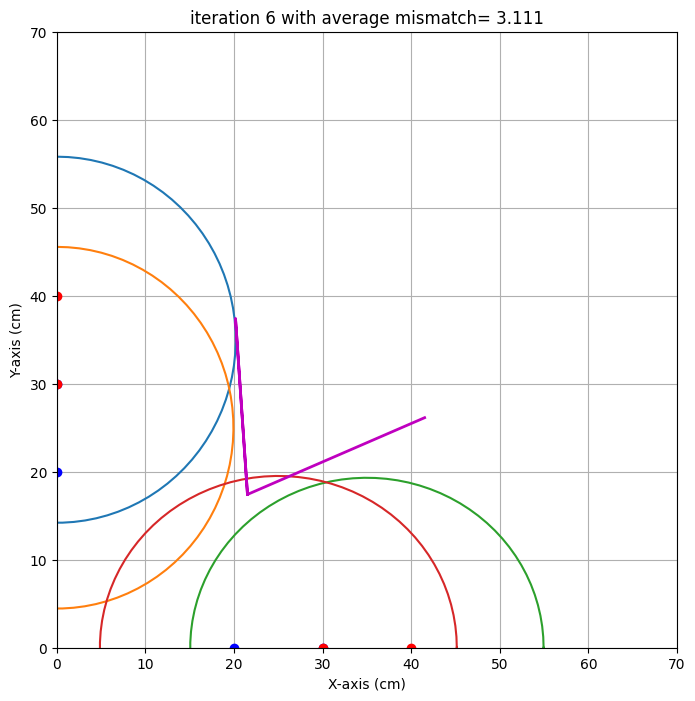

end iteration 6 with average mismatch= 3.111


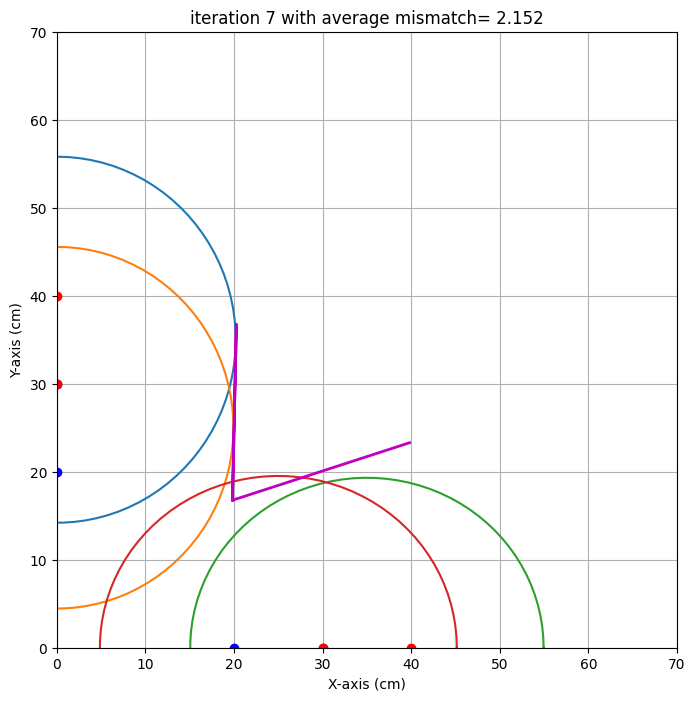

end iteration 7 with average mismatch= 2.152


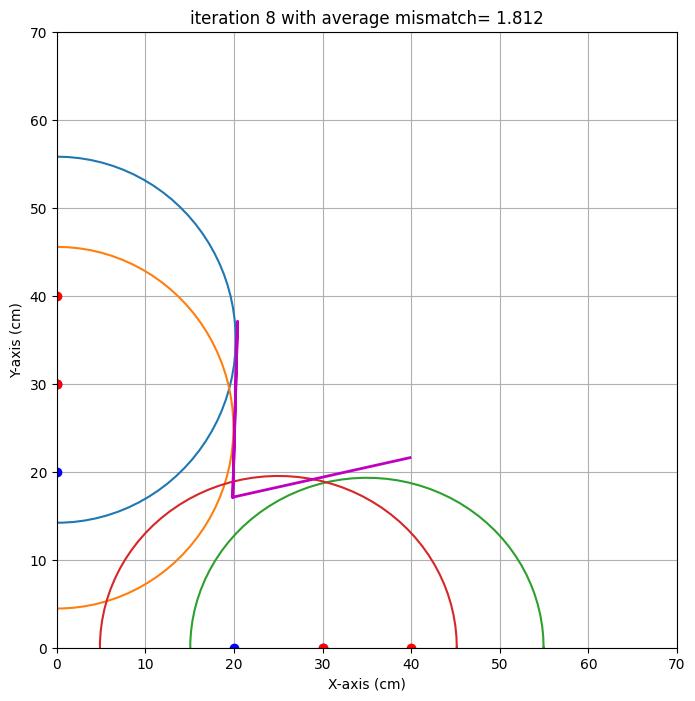

end iteration 8 with average mismatch= 1.812
end iteration 9 with average mismatch= 1.714
end iteration 10 with average mismatch= 1.668
end iteration 11 with average mismatch= 1.588


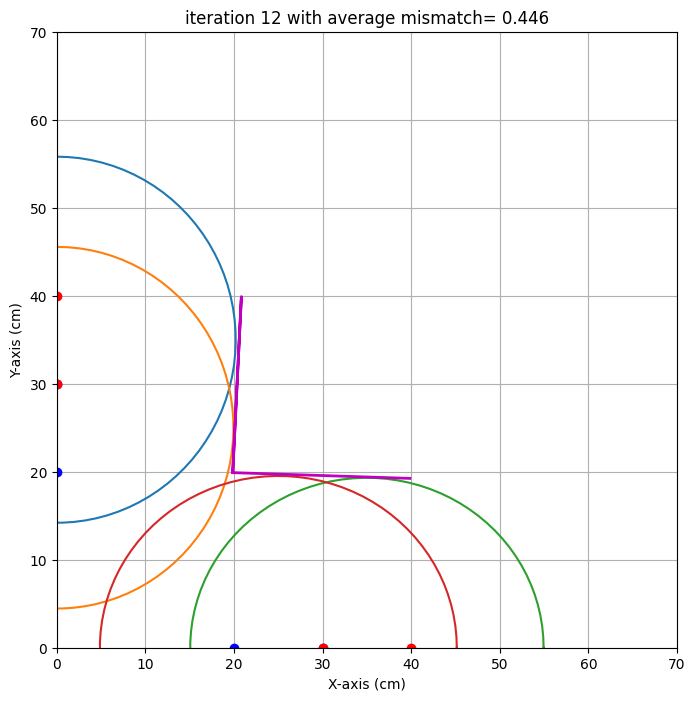

end iteration 12 with average mismatch= 0.446


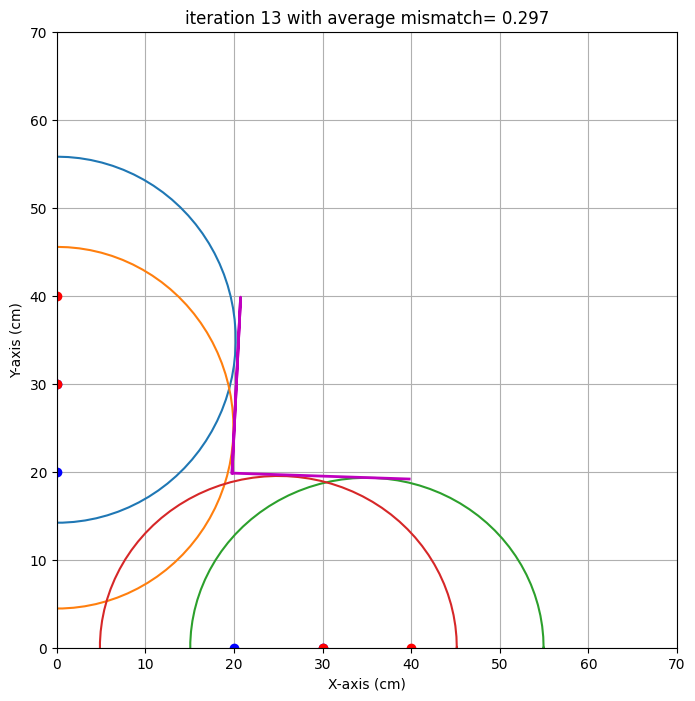

end iteration 13 with average mismatch= 0.297
end iteration 14 with average mismatch= 0.275
end iteration 15 with average mismatch= 0.267
end iteration 16 with average mismatch= 0.265
end iteration 17 with average mismatch= 0.264
end iteration 18 with average mismatch= 0.264
end iteration 19 with average mismatch= 0.263
end iteration 20 with average mismatch= 0.263
end iteration 21 with average mismatch= 0.263
end iteration 22 with average mismatch= 0.263
end iteration 23 with average mismatch= 0.263
end iteration 24 with average mismatch= 0.263
end iteration 25 with average mismatch= 0.263
end iteration 26 with average mismatch= 0.263
end iteration 27 with average mismatch= 0.263
end iteration 28 with average mismatch= 0.263
end iteration 29 with average mismatch= 0.263
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.263
######################################

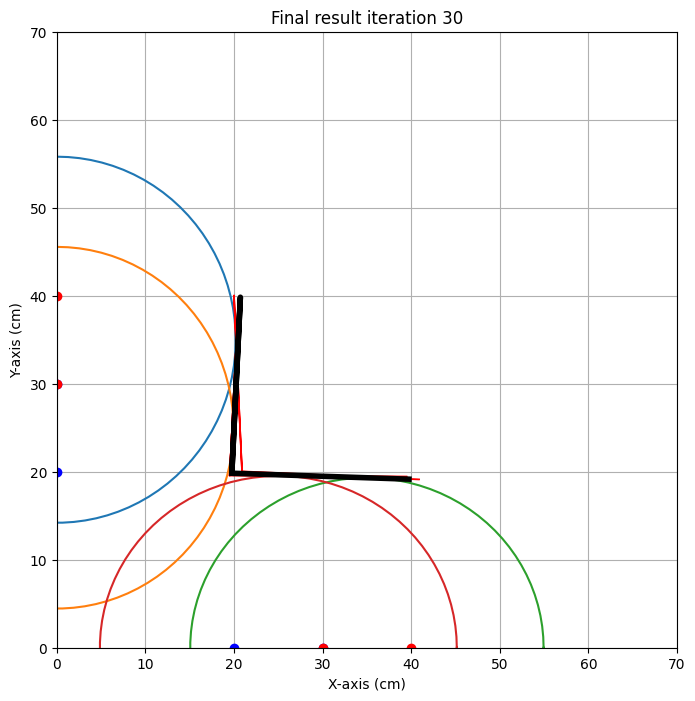

In [32]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.6],
    [0,30,0,20,41.1],
    #[0,10,0,20,180], deze meting was onrealistisch, dus uitgecomment
    [40,0,30,0,39.9],
    [30,0,20,0,40.3],
    #[10,0,20,0,199.98], deze meting ongeldig voor dezelfde reden, hij pakt de hoek
    #[10,0,0,10,187.63], deze meting ongeldig, nam de hoek mee    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [33]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.7 cm met een standaardafwijking van 1.2 cm 
y0: 19.8 cm met een standaardafwijking van 0.3 cm 
alpha: -1.9 graden met een standaardafwijking van 1.6 graad 
beta: 2.8 graden met een standaardafwijking van 5.4 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Kimi]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="iteratie0Kimi.jpeg" width="400">

#### algoritme [Frank]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Iteratie0Frank.jpeg" width="400">

geen derde student

In [34]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [35]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':35,
           'y0':32,#zelf aanvullen,
           'alpha' :30, #zelf aanvullen,
           'beta' : 0,#zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Frank' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,70,0,69.8],
    [45,0,20,0,66.8],
    #[0,45,0,70,x]
    [0,45,0,20,63.3],
    [0,60,0,20,71.6],
    [70,0,30,0,71.4]
    ]),
    'Kimi' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0,x],
    [50,0,60,0,84.2],
    [0,30,0,40,71.4],
    #[0,35,0,45,x],
    #[0,40,0,50,x],
    [0,35,0,45,67.9],
    [0,40,0,50,65.5]
    ])
      }

## Opdracht 7: Evaluatie.

Frank
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  70   0  69.8
1  45   0  20   0  66.8
2   0  45   0  20  63.3
3   0  60   0  20  71.6
4  70   0  30   0  71.4


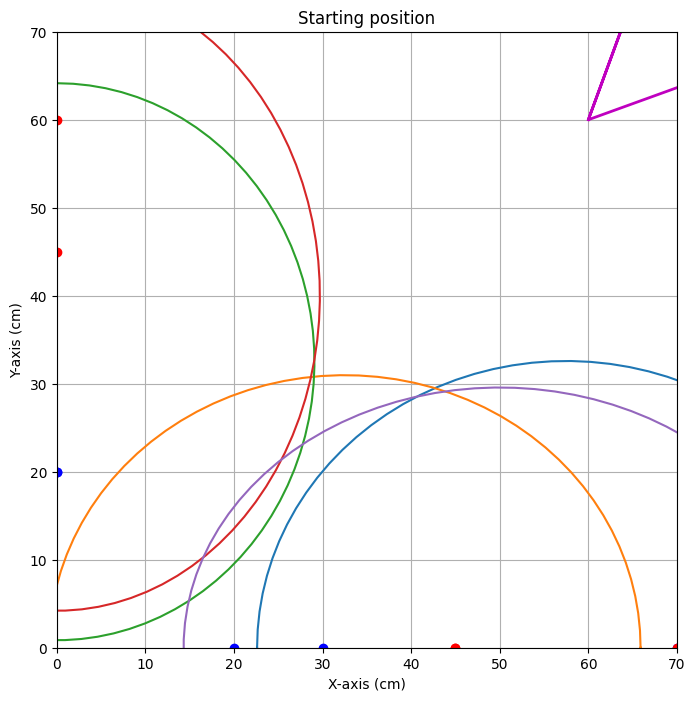


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.630


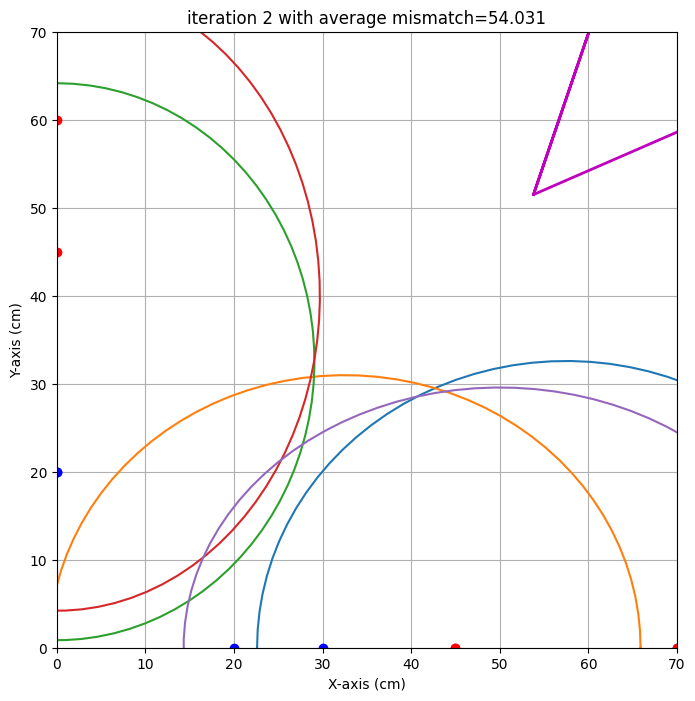

end iteration 2 with average mismatch=54.031


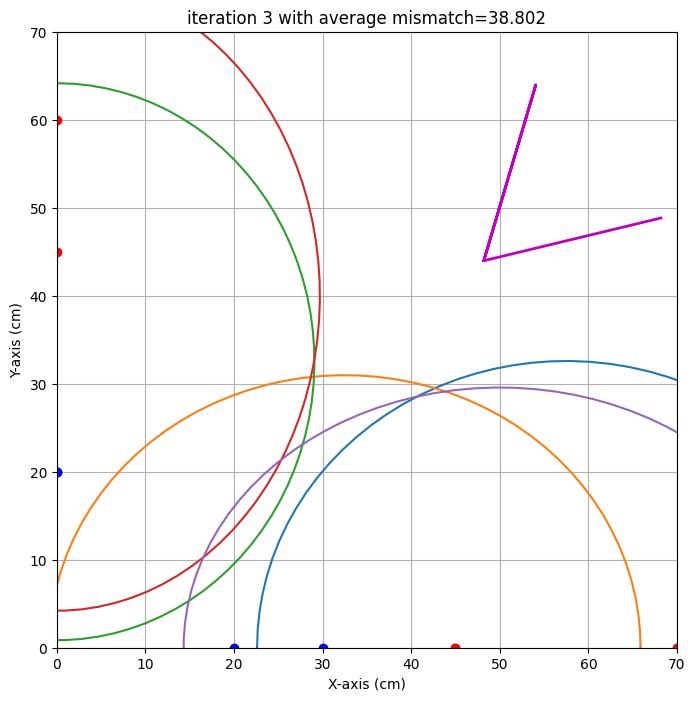

end iteration 3 with average mismatch=38.802


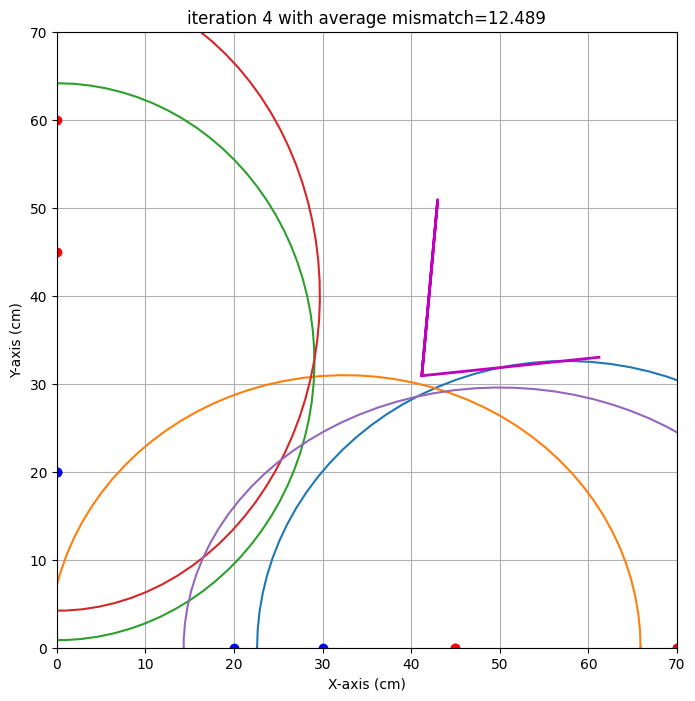

end iteration 4 with average mismatch=12.489


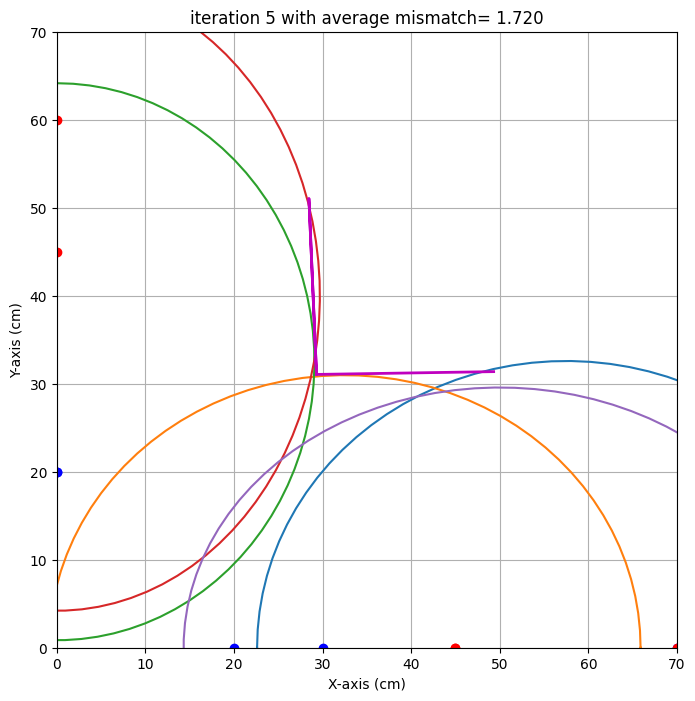

end iteration 5 with average mismatch= 1.720


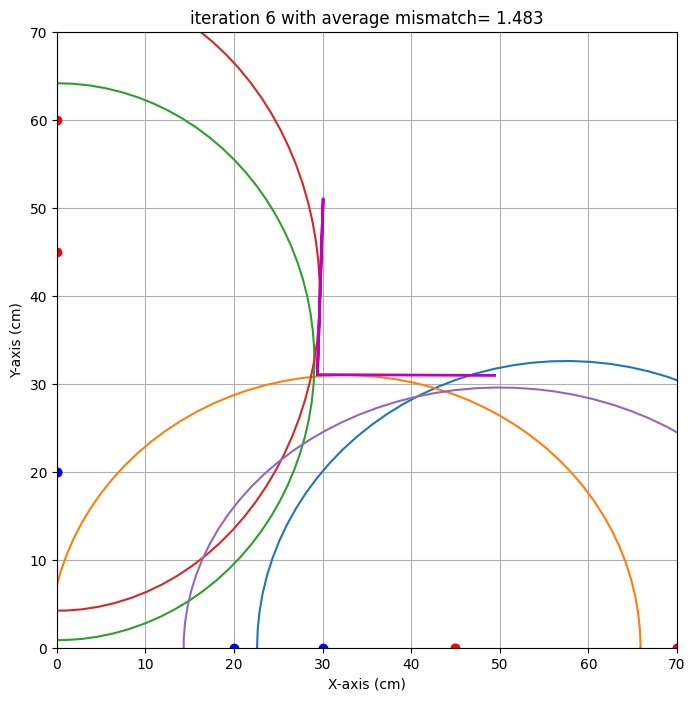

end iteration 6 with average mismatch= 1.483
end iteration 7 with average mismatch= 1.479
end iteration 8 with average mismatch= 1.478
end iteration 9 with average mismatch= 1.477
end iteration 10 with average mismatch= 1.477
end iteration 11 with average mismatch= 1.477
end iteration 12 with average mismatch= 1.477
end iteration 13 with average mismatch= 1.461
end iteration 14 with average mismatch= 1.453
end iteration 15 with average mismatch= 1.439
end iteration 16 with average mismatch= 1.437
end iteration 17 with average mismatch= 1.432
end iteration 18 with average mismatch= 1.415
end iteration 19 with average mismatch= 1.412
end iteration 20 with average mismatch= 1.411
end iteration 21 with average mismatch= 1.411
end iteration 22 with average mismatch= 1.411
end iteration 23 with average mismatch= 1.411
end iteration 24 with average mismatch= 1.411
end iteration 25 with average mismatch= 1.411
end iteration 26 with average mismatch= 1.388
end iteration 27 with average mismatch

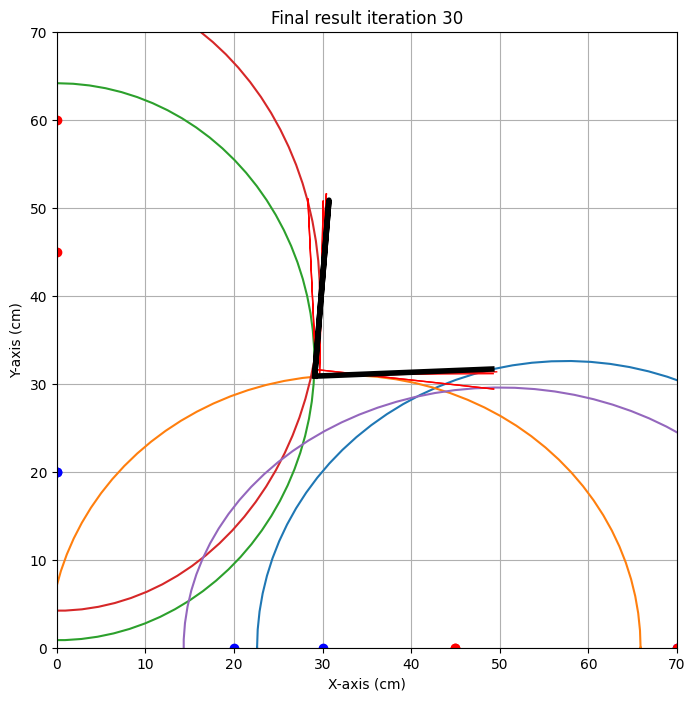

{'alpha': np.float64(2.3183758562620462), 'alpha_eps': np.float64(8.61121987901988), 'beta': np.float64(4.613159055712888), 'beta_eps': np.float64(7.25627475461428), 'x0': np.float64(29.10191952895198), 'x0_eps': np.float64(0.5480411148957565), 'y0': np.float64(30.858504243018114), 'y0_eps': np.float64(0.7445388926843677)}
Kimi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  84.2
1   0  30   0  40  71.4
2   0  35   0  45  67.9
3   0  40   0  50  65.5


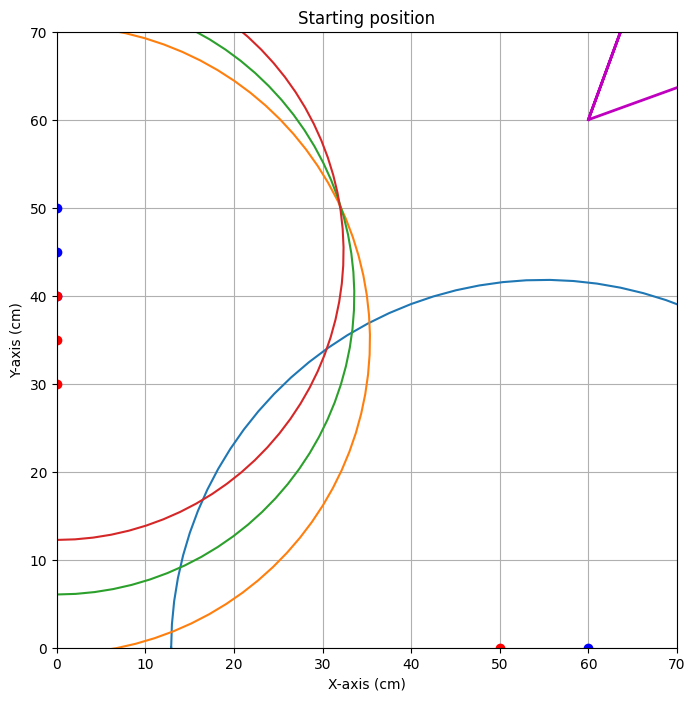


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=58.813


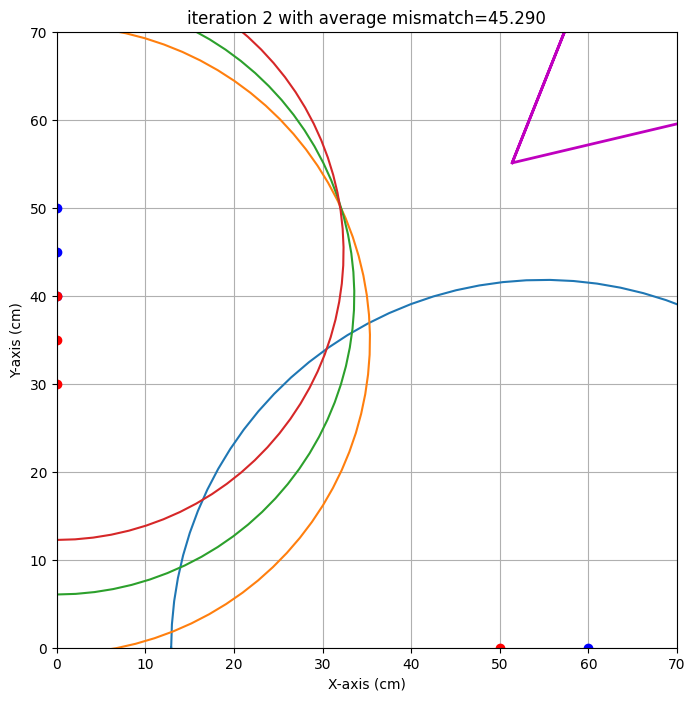

end iteration 2 with average mismatch=45.290


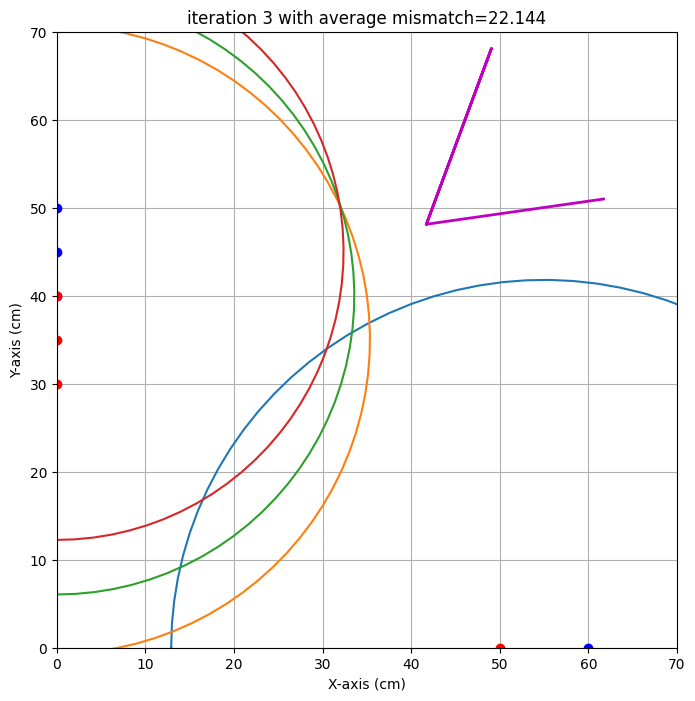

end iteration 3 with average mismatch=22.144


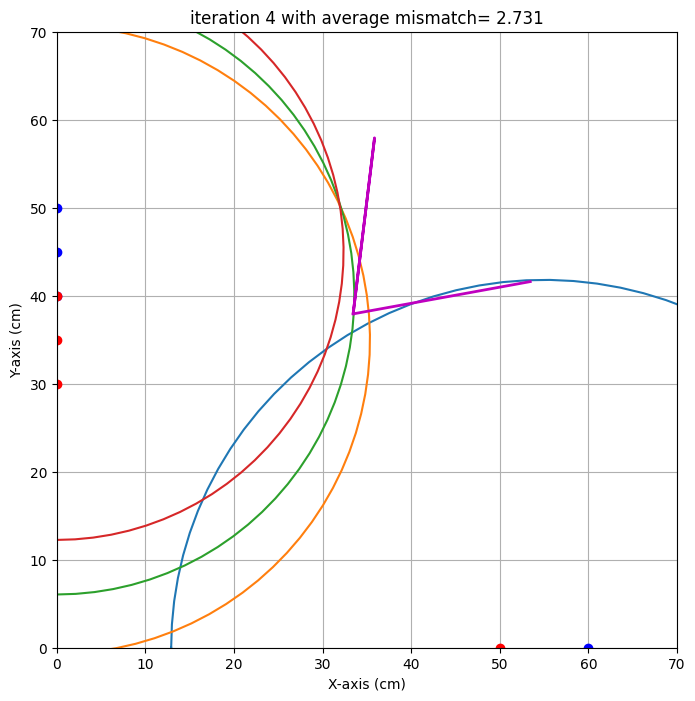

end iteration 4 with average mismatch= 2.731


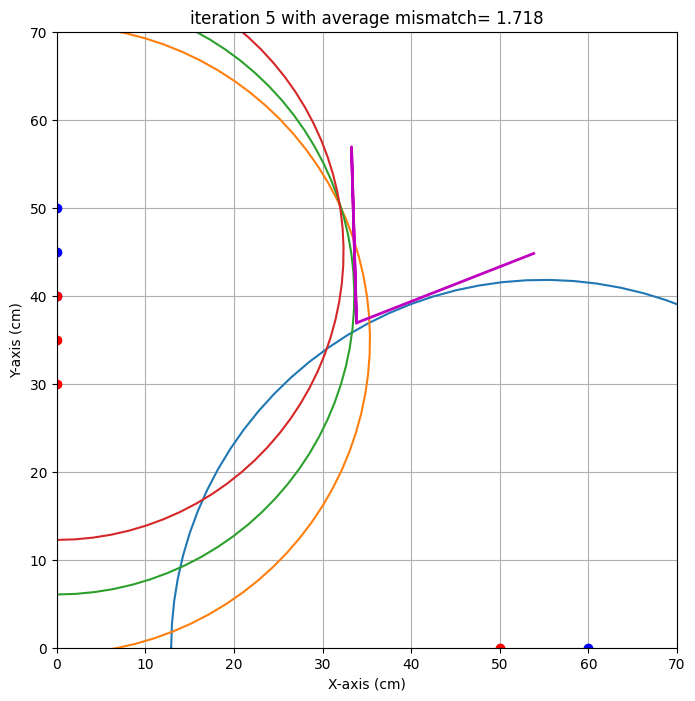

end iteration 5 with average mismatch= 1.718


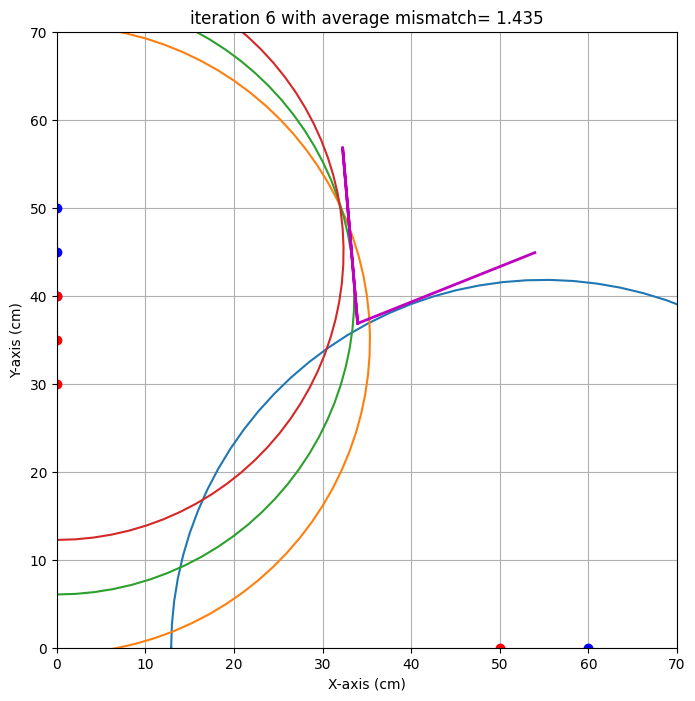

end iteration 6 with average mismatch= 1.435
end iteration 7 with average mismatch= 1.401


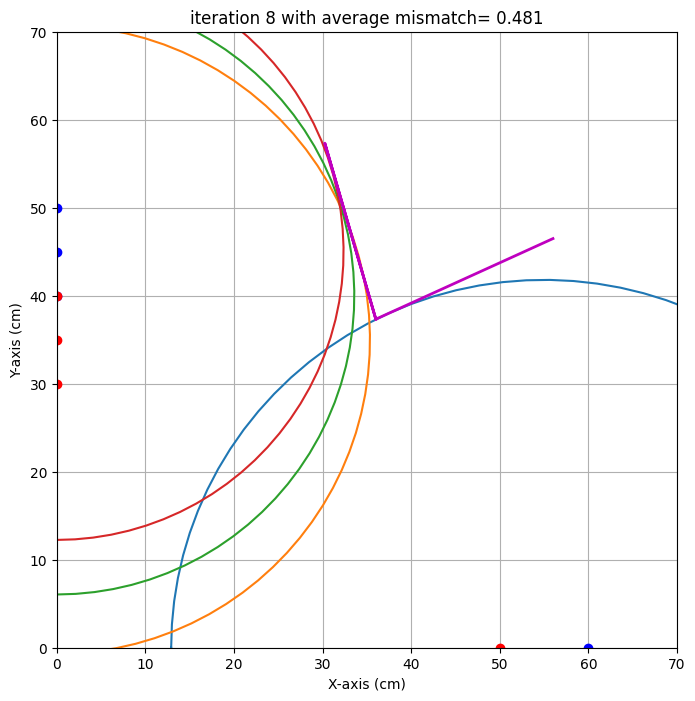

end iteration 8 with average mismatch= 0.481
end iteration 9 with average mismatch= 0.439


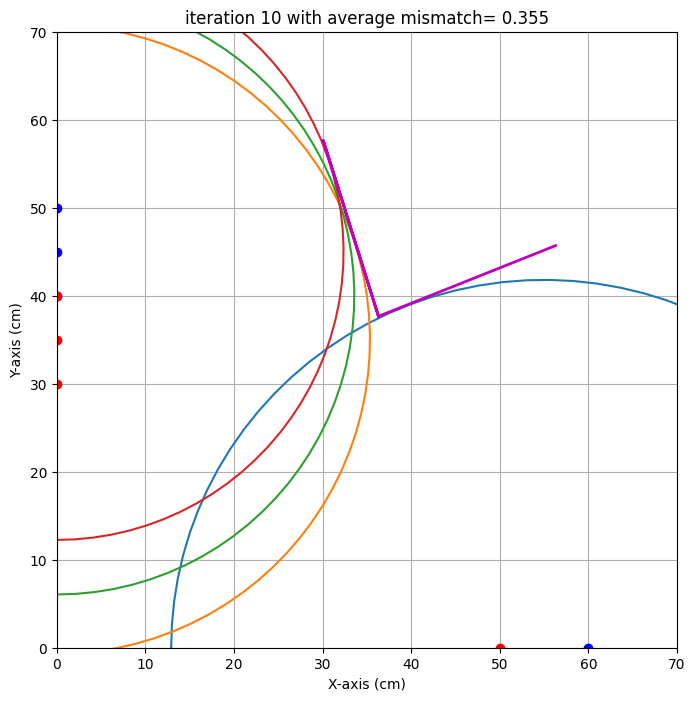

end iteration 10 with average mismatch= 0.355


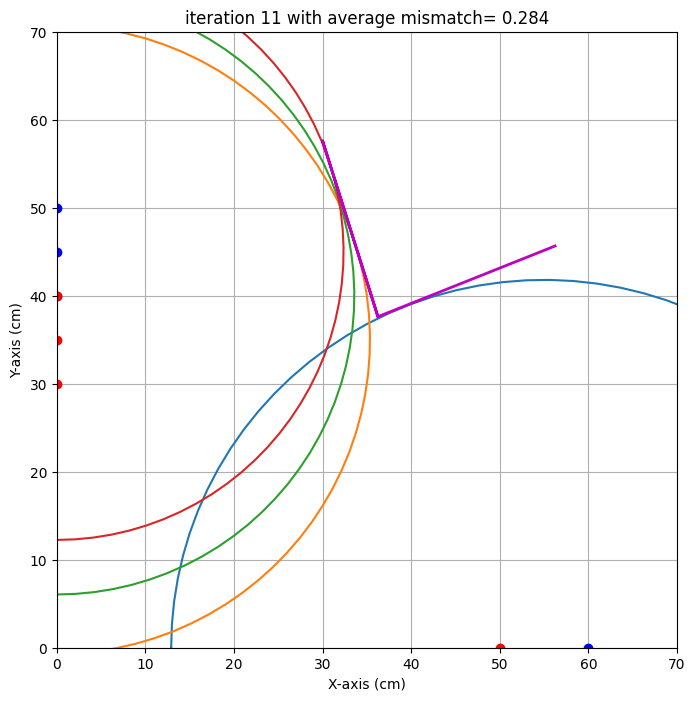

end iteration 11 with average mismatch= 0.284
end iteration 12 with average mismatch= 0.284
end iteration 13 with average mismatch= 0.284
end iteration 14 with average mismatch= 0.284
end iteration 15 with average mismatch= 0.284
end iteration 16 with average mismatch= 0.284
end iteration 17 with average mismatch= 0.284
end iteration 18 with average mismatch= 0.284
end iteration 19 with average mismatch= 0.284
end iteration 20 with average mismatch= 0.284
end iteration 21 with average mismatch= 0.284
end iteration 22 with average mismatch= 0.284
end iteration 23 with average mismatch= 0.284
end iteration 24 with average mismatch= 0.284
end iteration 25 with average mismatch= 0.284
end iteration 26 with average mismatch= 0.284
end iteration 27 with average mismatch= 0.284
end iteration 28 with average mismatch= 0.284
end iteration 29 with average mismatch= 0.284
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little lon

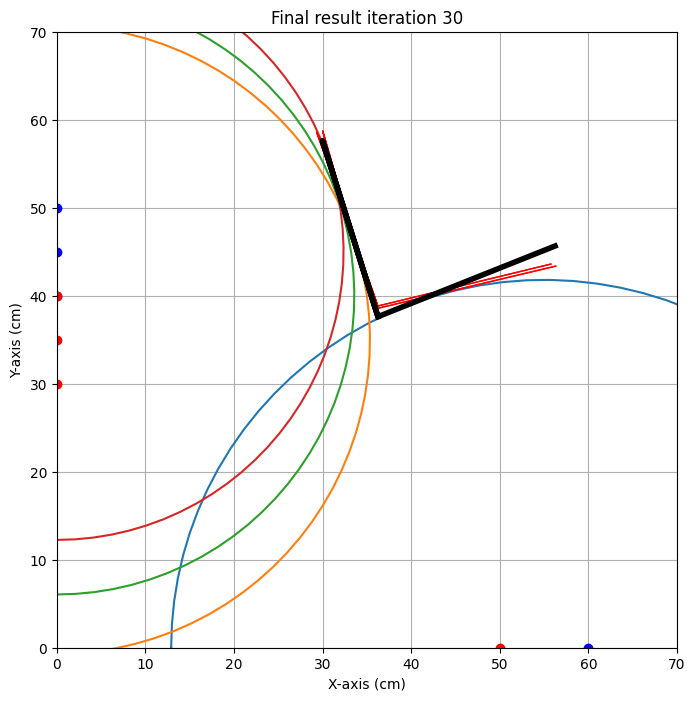

{'alpha': np.float64(21.880195099595902), 'alpha_eps': np.float64(8.458355142036773), 'beta': np.float64(-17.36984398644297), 'beta_eps': np.float64(1.8853483664345738), 'x0': np.float64(36.24448601191651), 'x0_eps': np.float64(0.4756773361160569), 'y0': np.float64(37.619998254989156), 'y0_eps': np.float64(1.0964536038724475)}


In [36]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [37]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Frank 
x0 target is : 35.0. Gevonden waarde: 29.1 cm met een standaardafwijking van 0.5 cm 
y0 target is : 32.0. Gevonden waarde: 30.9 cm met een standaardafwijking van 0.7 cm 
alpha target is : 30.0. Gevonden waarde: 2.3 graden met een standaardafwijking van 8.6 graad 
beta target is : 0.0. Gevonden waarde: 4.6 graden met een standaardafwijking van 7.3 graad 

Kimi 
x0 target is : 35.0. Gevonden waarde: 36.2 cm met een standaardafwijking van 0.5 cm 
y0 target is : 32.0. Gevonden waarde: 37.6 cm met een standaardafwijking van 1.1 cm 
alpha target is : 30.0. Gevonden waarde: 21.9 graden met een standaardafwijking van 8.5 graad 
beta target is : 0.0. Gevonden waarde: -17.4 graden met een standaardafwijking van 1.9 graad 



## Opdracht 8: Iteratie1+.14:20.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Iteratie1.jpeg)


## Iteratie 15:02.

Nu naar iteratie 2

Figuur: ![Alt](iteratie2.jpeg)

In [38]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  20   0  61.0
1  70   0  30   0  70.2
2   0  45   0  20  56.9
3   0  45   0  70  65.9
4  20   0  70   0  77.1
5   0  70   0  20  73.3


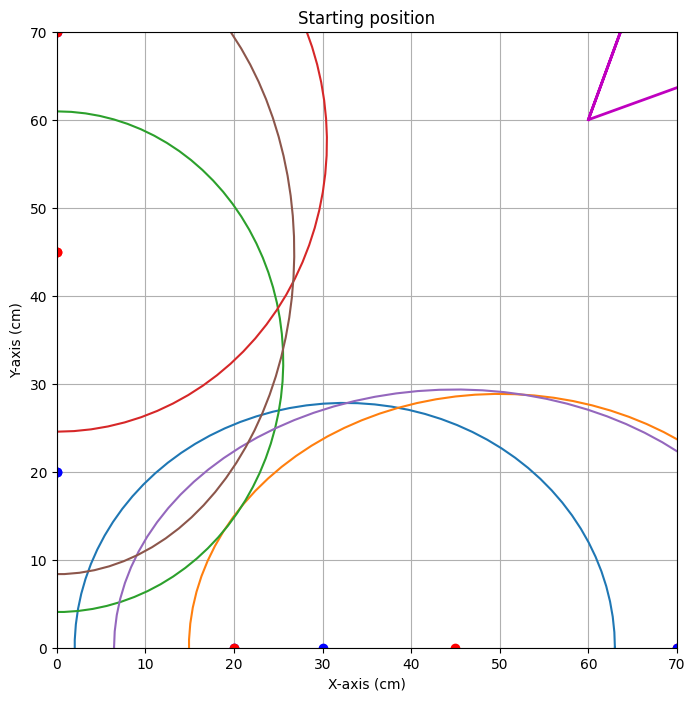


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.422


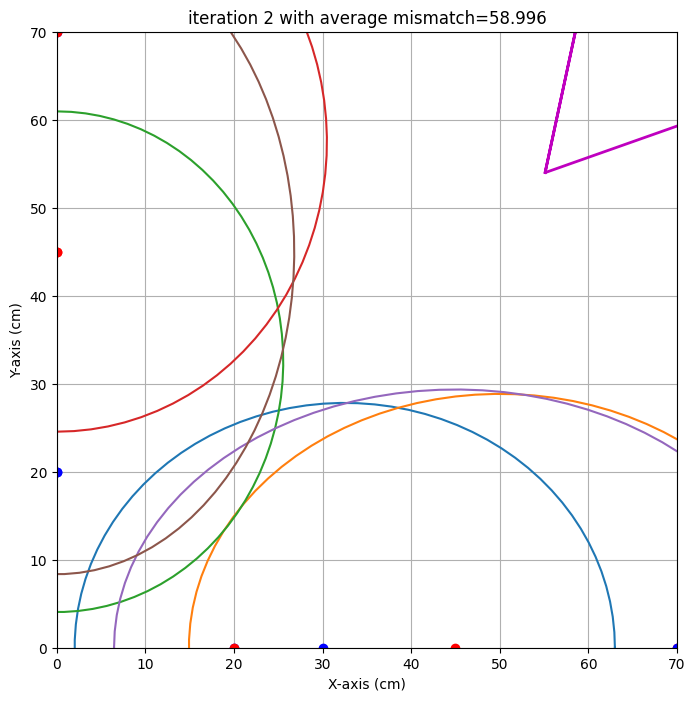

end iteration 2 with average mismatch=58.996


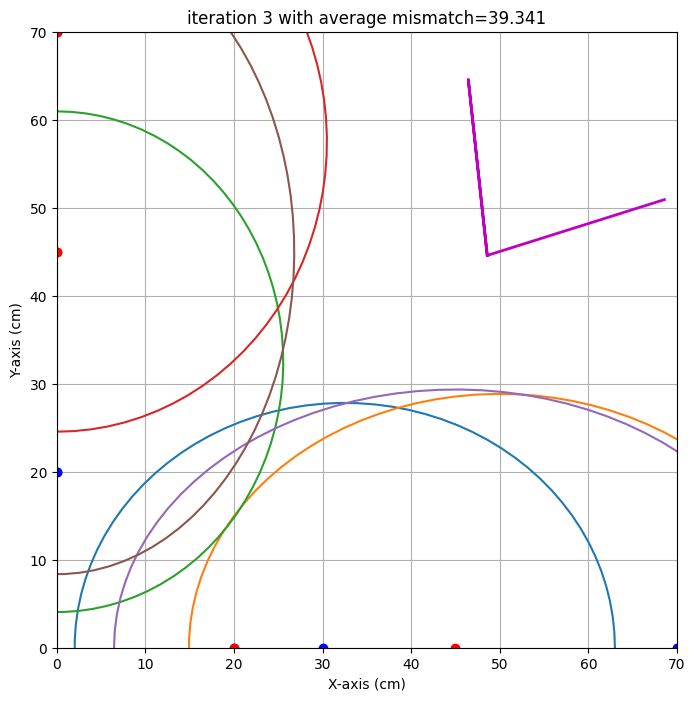

end iteration 3 with average mismatch=39.341


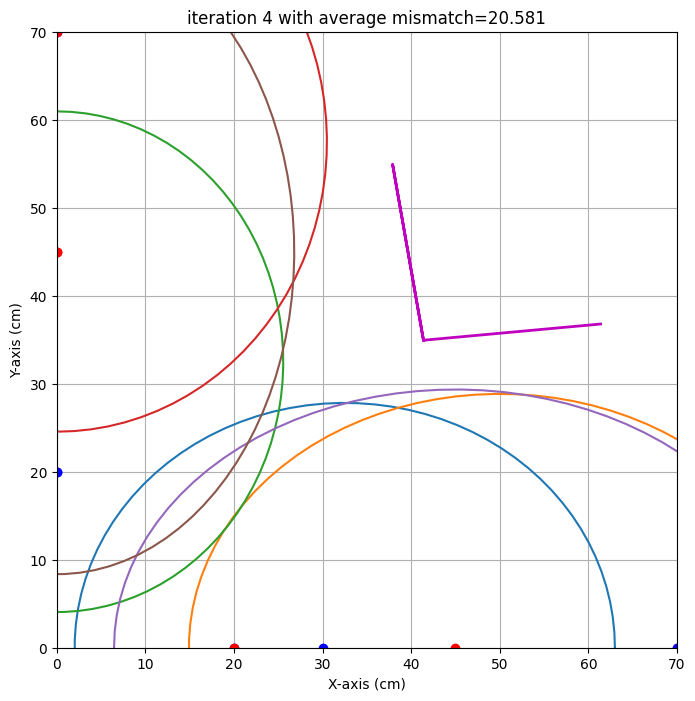

end iteration 4 with average mismatch=20.581


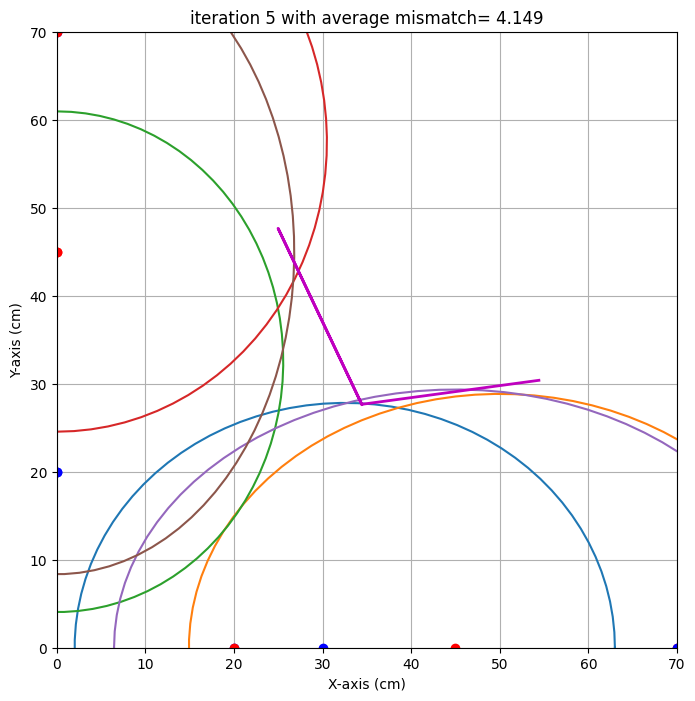

end iteration 5 with average mismatch= 4.149


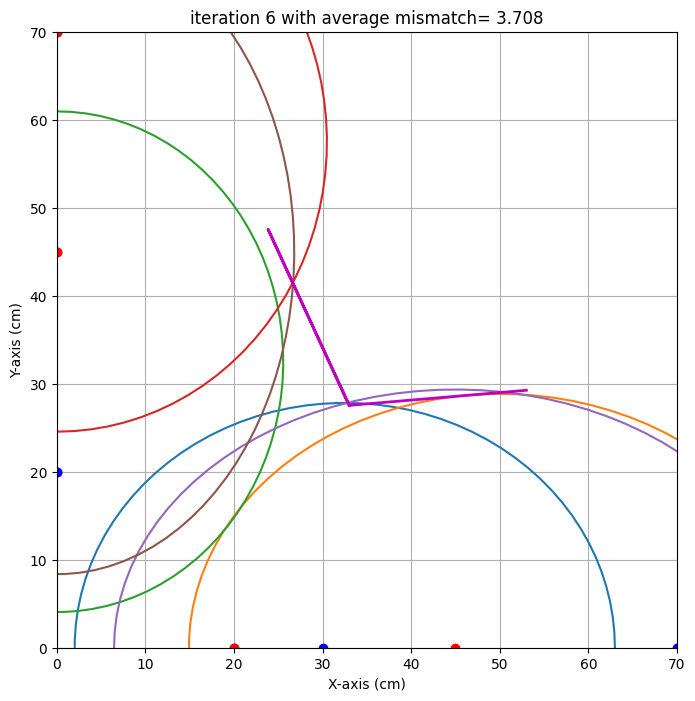

end iteration 6 with average mismatch= 3.708
end iteration 7 with average mismatch= 3.643
end iteration 8 with average mismatch= 3.629
end iteration 9 with average mismatch= 3.463
end iteration 10 with average mismatch= 3.235
end iteration 11 with average mismatch= 3.235
end iteration 12 with average mismatch= 3.210


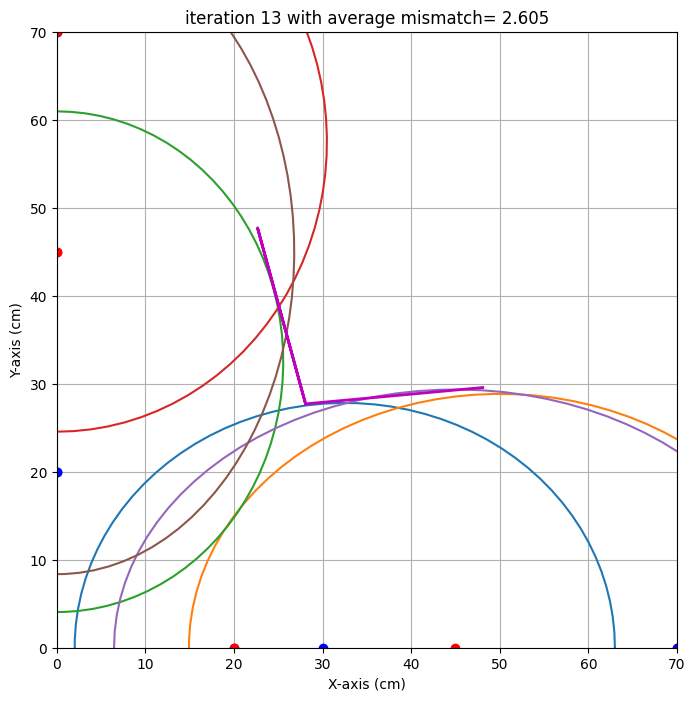

end iteration 13 with average mismatch= 2.605
end iteration 14 with average mismatch= 2.555
end iteration 15 with average mismatch= 2.555
end iteration 16 with average mismatch= 2.320


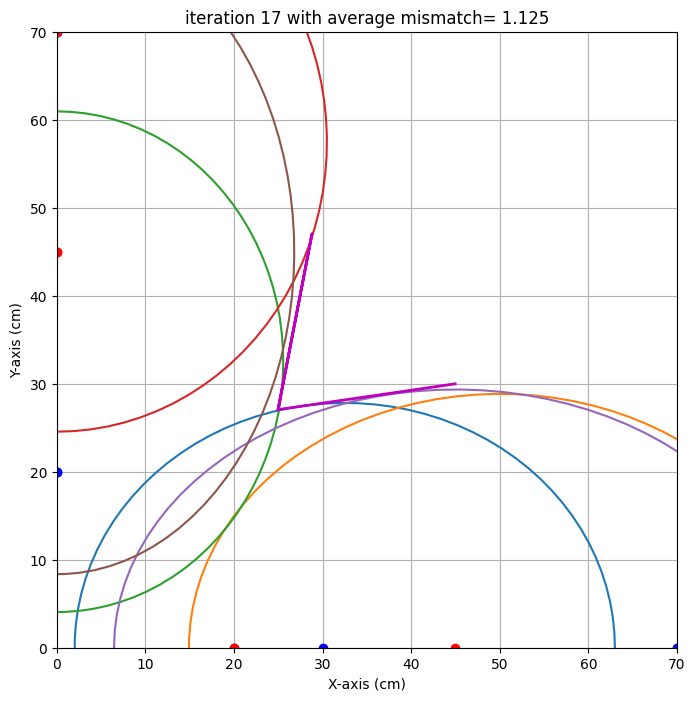

end iteration 17 with average mismatch= 1.125
end iteration 18 with average mismatch= 1.059
end iteration 19 with average mismatch= 1.058
end iteration 20 with average mismatch= 1.058
end iteration 21 with average mismatch= 1.058
end iteration 22 with average mismatch= 1.058
end iteration 23 with average mismatch= 1.058
end iteration 24 with average mismatch= 1.058
end iteration 25 with average mismatch= 1.058
end iteration 26 with average mismatch= 1.058
end iteration 27 with average mismatch= 1.005
end iteration 28 with average mismatch= 0.970
end iteration 29 with average mismatch= 0.970
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.970
###############################################################################
end of iteration  30
Best alpha=   7.88 with uncertainty=   5.19
Best beta =  10.50 with uncertainty=   3.34
Best x0   =  25.04 with uncertainty=   0.38
Best y0   =  2

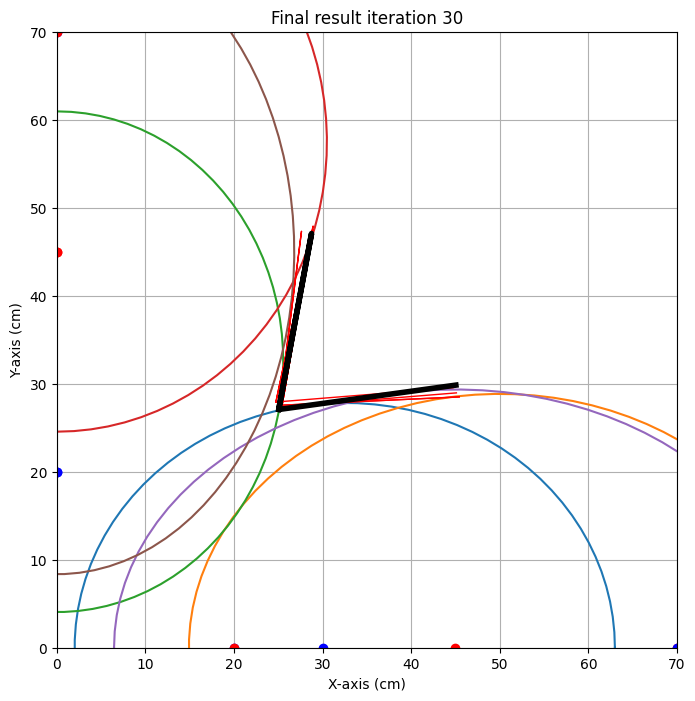

{'alpha': np.float64(7.88313820944892), 'alpha_eps': np.float64(5.191481483618019), 'beta': np.float64(10.501012037235926), 'beta_eps': np.float64(3.3440413166254093), 'x0': np.float64(25.044304119714567), 'x0_eps': np.float64(0.38041482421217765), 'y0': np.float64(27.07186072367773), 'y0_eps': np.float64(0.8477131867454943)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  85.2
1  45   0  70   0  87.5
2   0  40   0  60  82.3
3   0  45   0  70  84.0


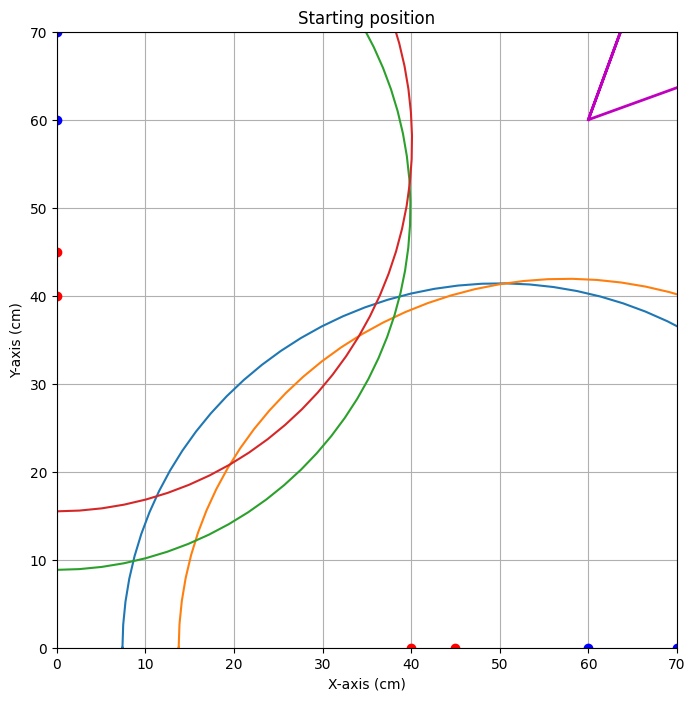


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.962


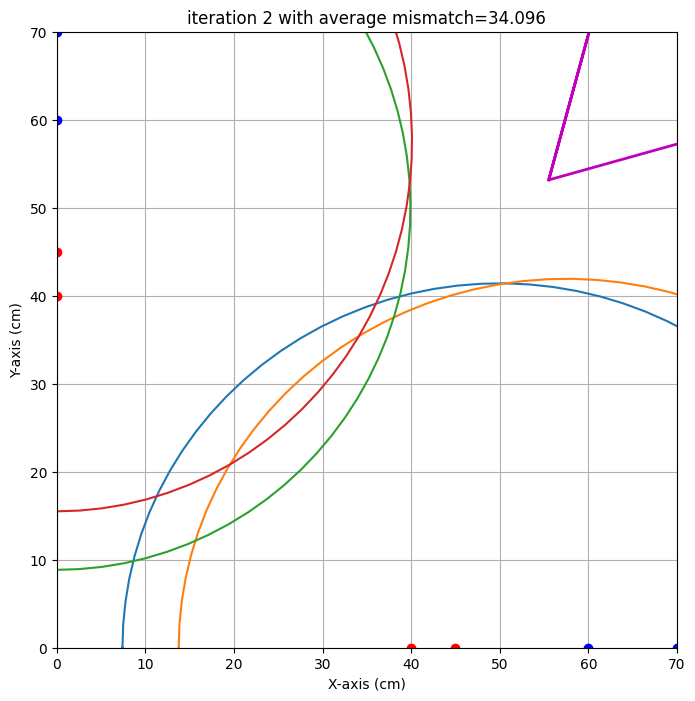

end iteration 2 with average mismatch=34.096


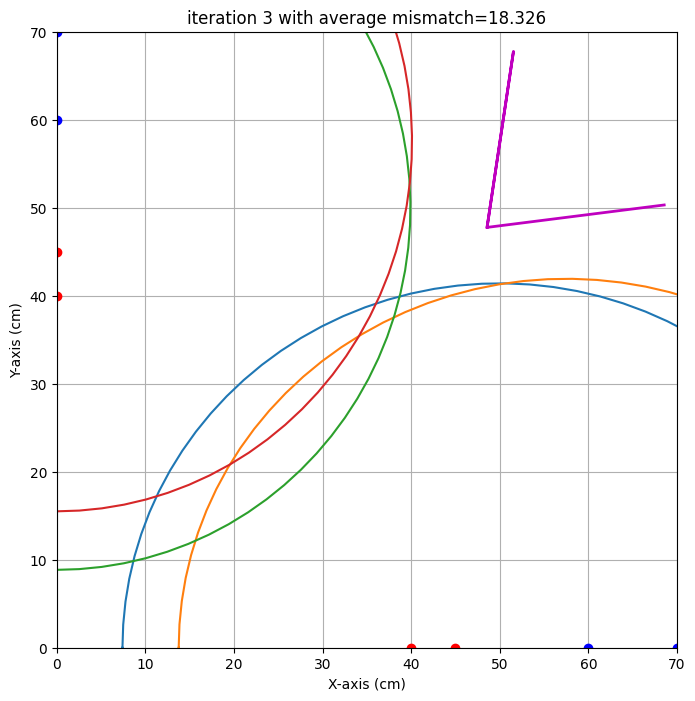

end iteration 3 with average mismatch=18.326


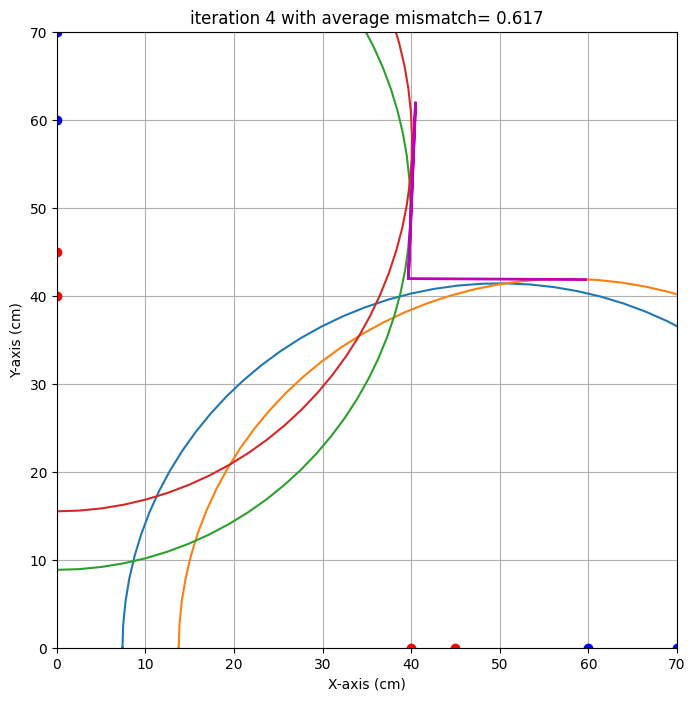

end iteration 4 with average mismatch= 0.617


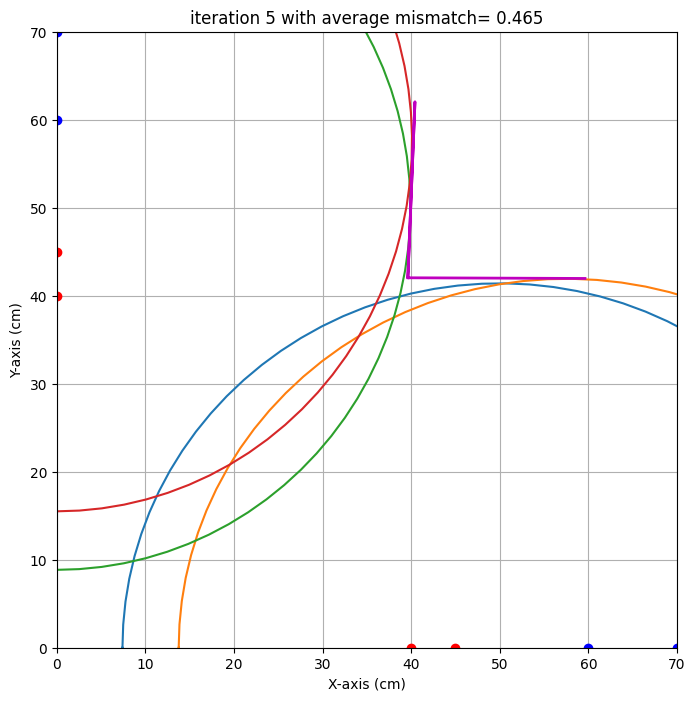

end iteration 5 with average mismatch= 0.465
end iteration 6 with average mismatch= 0.458


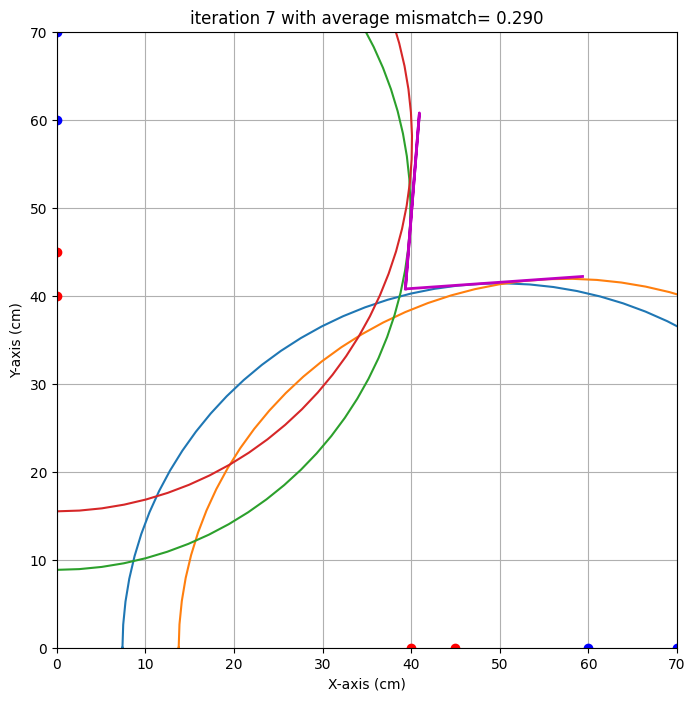

end iteration 7 with average mismatch= 0.290
end iteration 8 with average mismatch= 0.278
end iteration 9 with average mismatch= 0.271
end iteration 10 with average mismatch= 0.266
end iteration 11 with average mismatch= 0.266
end iteration 12 with average mismatch= 0.251


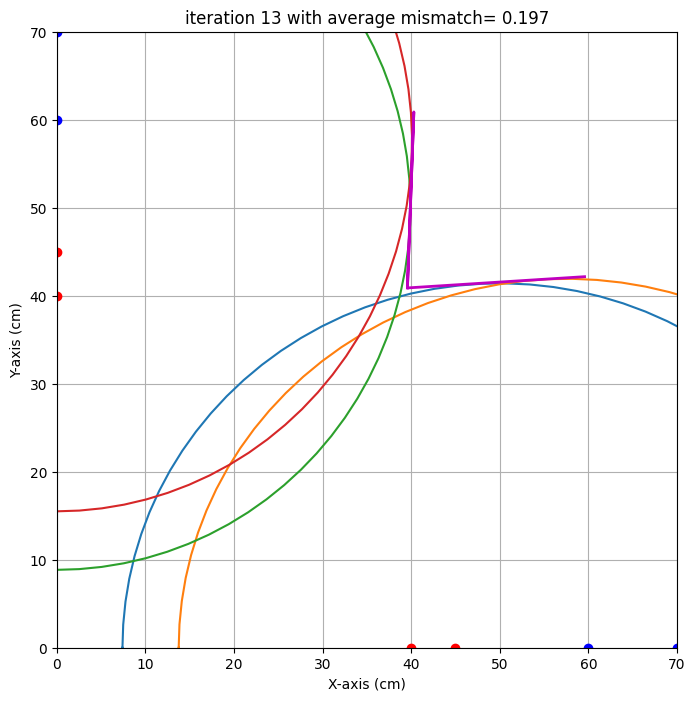

end iteration 13 with average mismatch= 0.197
end iteration 14 with average mismatch= 0.188
end iteration 15 with average mismatch= 0.187
end iteration 16 with average mismatch= 0.187
end iteration 17 with average mismatch= 0.187
end iteration 18 with average mismatch= 0.187
end iteration 19 with average mismatch= 0.187
end iteration 20 with average mismatch= 0.187
end iteration 21 with average mismatch= 0.187
end iteration 22 with average mismatch= 0.187
end iteration 23 with average mismatch= 0.187
end iteration 24 with average mismatch= 0.187


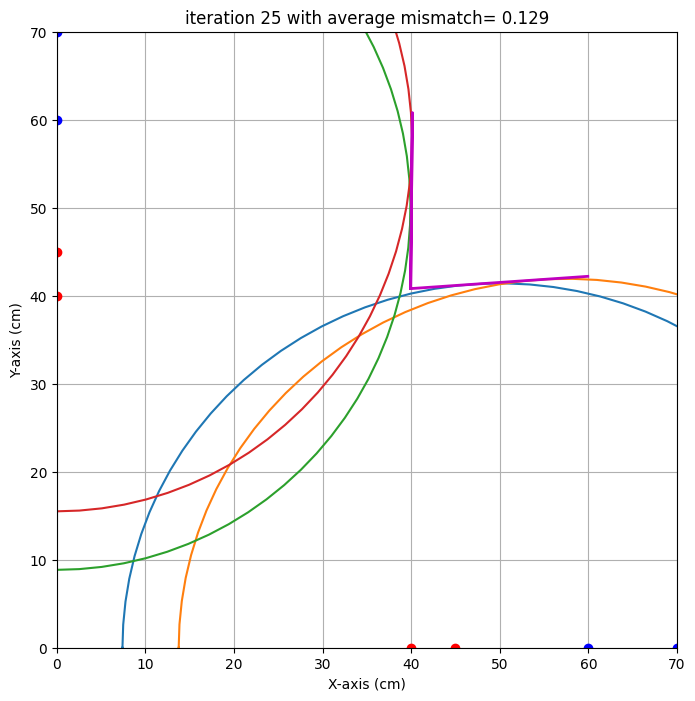

end iteration 25 with average mismatch= 0.129
end iteration 26 with average mismatch= 0.128
end iteration 27 with average mismatch= 0.128
end iteration 28 with average mismatch= 0.128
end iteration 29 with average mismatch= 0.128
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.128
###############################################################################
end of iteration  30
Best alpha=   3.98 with uncertainty=   0.36
Best beta =   0.54 with uncertainty=   3.95
Best x0   =  39.94 with uncertainty=   0.81
Best y0   =  40.81 with uncertainty=   0.30
###############################################################################


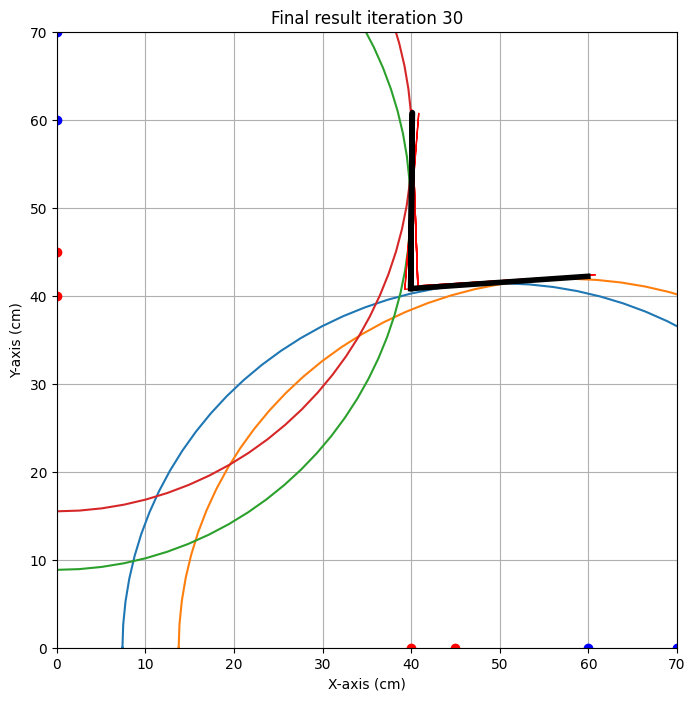

{'alpha': np.float64(3.983627606718149), 'alpha_eps': np.float64(0.36164810010191806), 'beta': np.float64(0.5420022538359339), 'beta_eps': np.float64(3.9479526690292426), 'x0': np.float64(39.94037838526425), 'x0_eps': np.float64(0.8142415782076498), 'y0': np.float64(40.80967555478917), 'y0_eps': np.float64(0.3043496811422628)}
locatie 1 
x0 target is : 22.0. Gevonden waarde: 25.0 cm met een standaardafwijking van 0.4 cm 
y0 target is : 26.0. Gevonden waarde: 27.1 cm met een standaardafwijking van 0.8 cm 
alpha target is : 10.0. Gevonden waarde: 7.9 graden met een standaardafwijking van 5.2 graad 
beta target is : 20.0. Gevonden waarde: 10.5 graden met een standaardafwijking van 3.3 graad 

locatie 2 
x0 target is : 39.0. Gevonden waarde: 39.9 cm met een standaardafwijking van 0.8 cm 
y0 target is : 39.0. Gevonden waarde: 40.8 cm met een standaardafwijking van 0.3 cm 
alpha target is : 5.0. Gevonden waarde: 4.0 graden met een standaardafwijking van 0.4 graad 
beta target is : 5.0. Gevon

In [39]:
# Voeg hier je meetgegevens van deze iteratie in:
# Dit is iteratie 1

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':22,
                    'y0':26,
                    'alpha' : 10,
                    'beta' : 20,},
            'locatie 2':{'x0':39,
                     'y0':39,
                     'alpha' : 5,
                     'beta' : 5}
             }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45, 0, 20, 0, 61.0],
    [70, 0, 30, 0, 70.2],
    [0, 45, 0, 20, 56.9],
    [0, 45, 0, 70, 65.9],
    [20, 0, 70, 0, 77.1],
    [0, 70, 0, 20, 73.3],
    ]),
        'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, -]
    [40, 0, 60, 0, 85.2],
    [45, 0, 70, 0, 87.5],
    #[0, 45, 0, 20, -]
    [0, 40, 0, 60, 82.3],
    [0, 45, 0, 70, 84.0]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  71.6
1  45   0  70   0  78.3
2   0  45   0  20  89.0
3   0  45   0  70  85.4
4  20   0  70   0  88.4
5   0  70   0  20  93.6
6   0  25   0  45  86.4
7   0  50   0  65  83.5
8  50   0  65   0  76.0


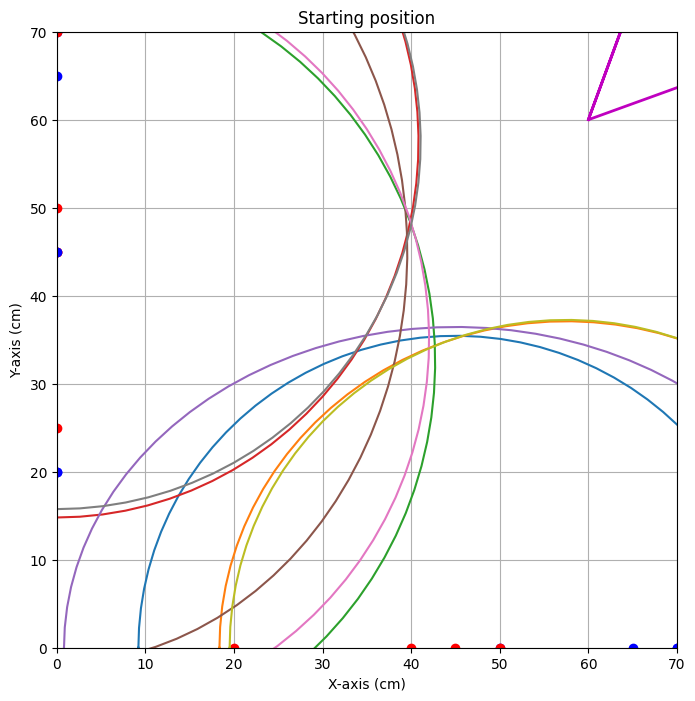


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=49.270


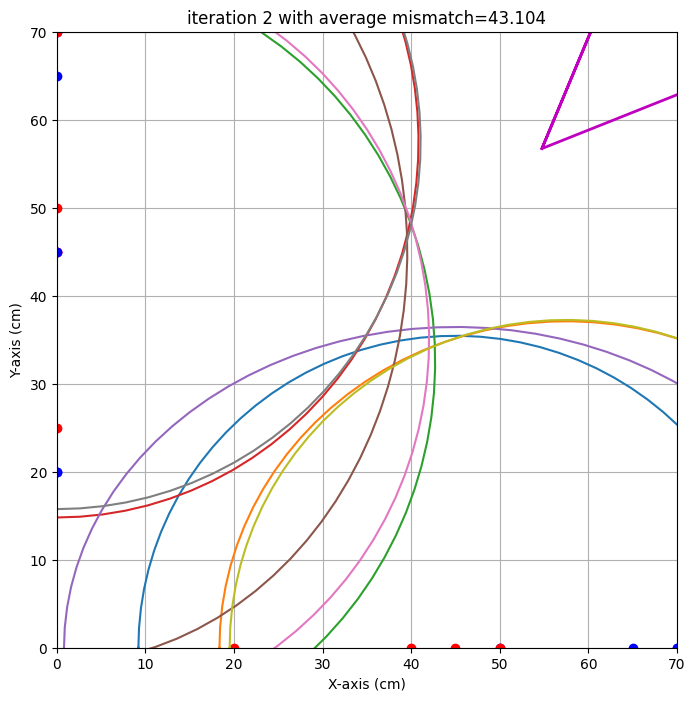

end iteration 2 with average mismatch=43.104


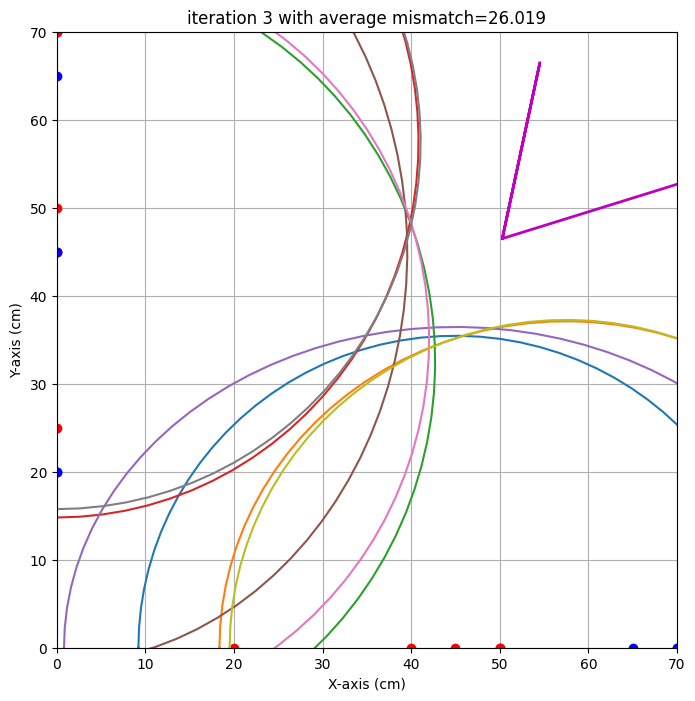

end iteration 3 with average mismatch=26.019


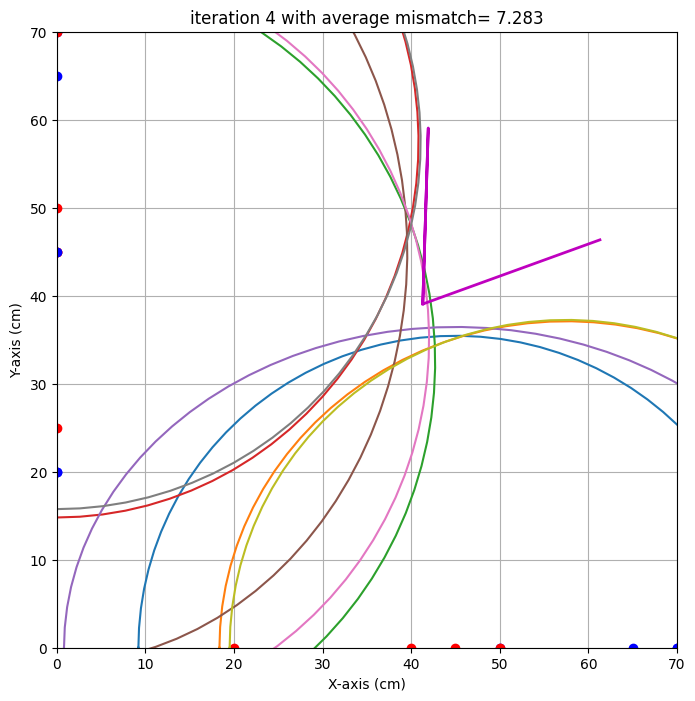

end iteration 4 with average mismatch= 7.283


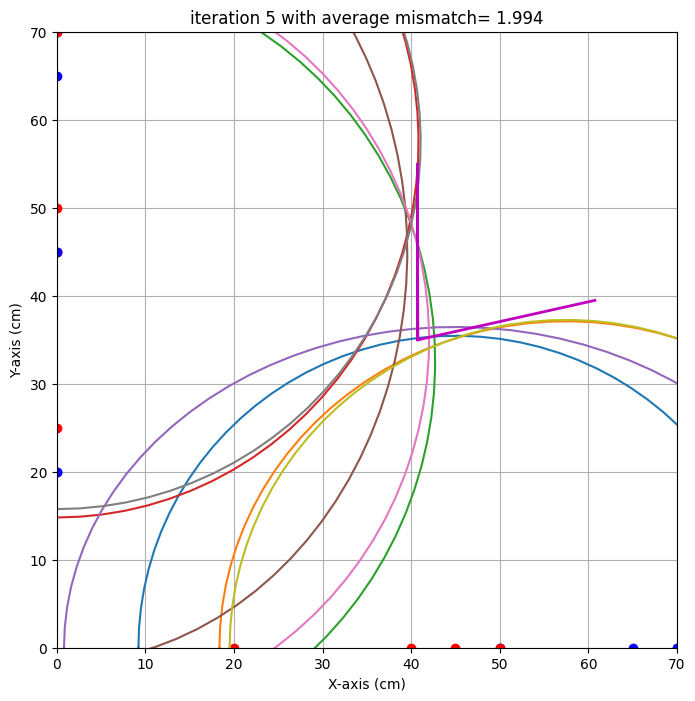

end iteration 5 with average mismatch= 1.994
end iteration 6 with average mismatch= 1.964


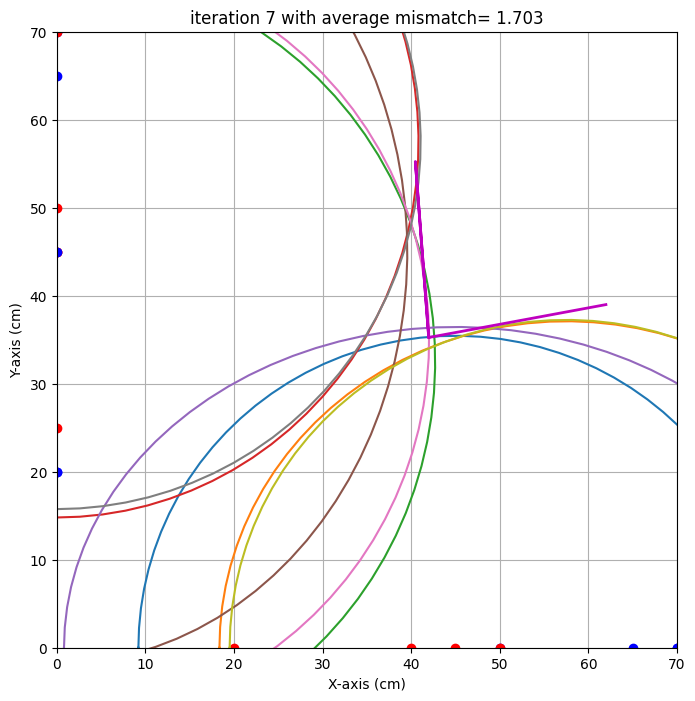

end iteration 7 with average mismatch= 1.703
end iteration 8 with average mismatch= 1.649
end iteration 9 with average mismatch= 1.626
end iteration 10 with average mismatch= 1.619
end iteration 11 with average mismatch= 1.616
end iteration 12 with average mismatch= 1.613
end iteration 13 with average mismatch= 1.534
end iteration 14 with average mismatch= 1.534
end iteration 15 with average mismatch= 1.477
end iteration 16 with average mismatch= 1.468
end iteration 17 with average mismatch= 1.468
end iteration 18 with average mismatch= 1.468
end iteration 19 with average mismatch= 1.468
end iteration 20 with average mismatch= 1.468
end iteration 21 with average mismatch= 1.468
end iteration 22 with average mismatch= 1.468
end iteration 23 with average mismatch= 1.468
end iteration 24 with average mismatch= 1.468
end iteration 25 with average mismatch= 1.468
end iteration 26 with average mismatch= 1.468
end iteration 27 with average mismatch= 1.468
end iteration 28 with average mismatc

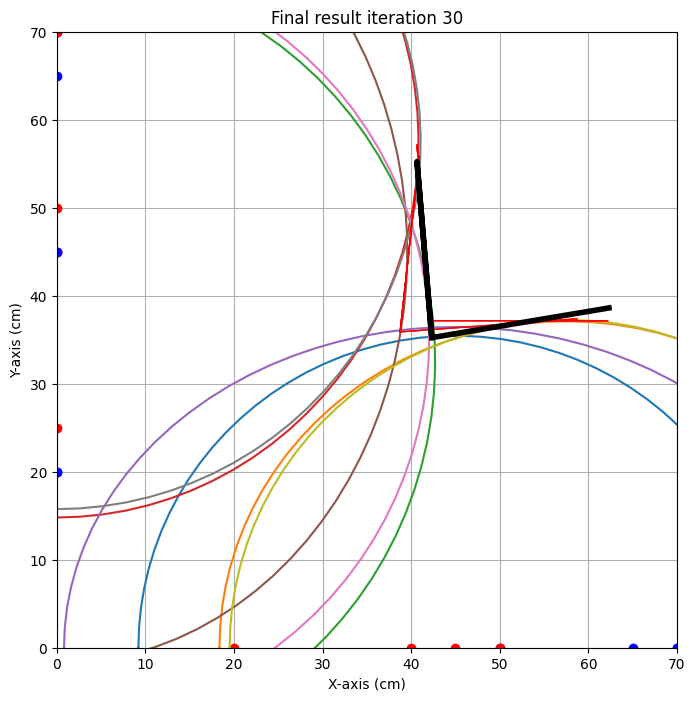

{'alpha': np.float64(9.569463505749294), 'alpha_eps': np.float64(9.613110753729767), 'beta': np.float64(-4.779777519402898), 'beta_eps': np.float64(10.940158276947), 'x0': np.float64(42.32669817295068), 'x0_eps': np.float64(3.574694227040034), 'y0': np.float64(35.23869174028001), 'y0_eps': np.float64(1.9156834219536876)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  85.1
1  45   0  70   0  86.8
2   0  40   0  60  88.5
3   0  45   0  70  92.5
4   0  50   0  65  89.0
5  50   0  65   0  84.5


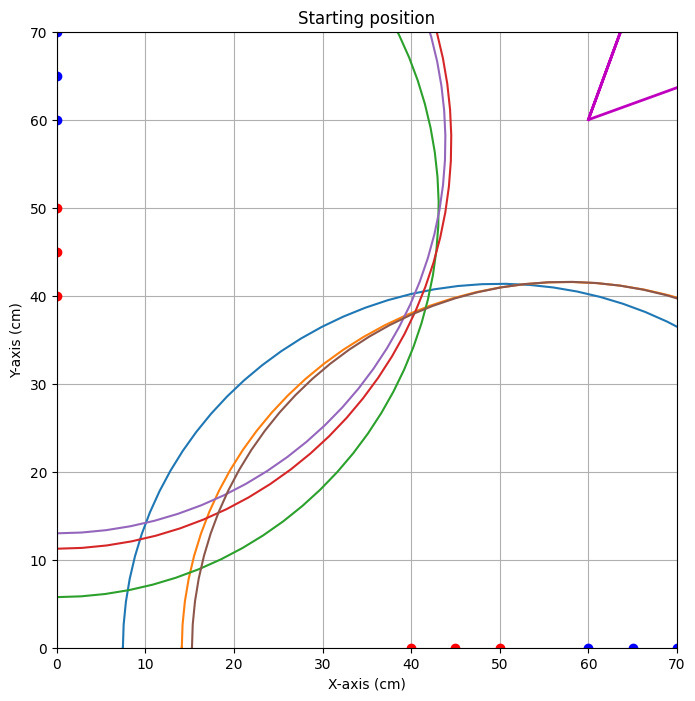


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=40.258


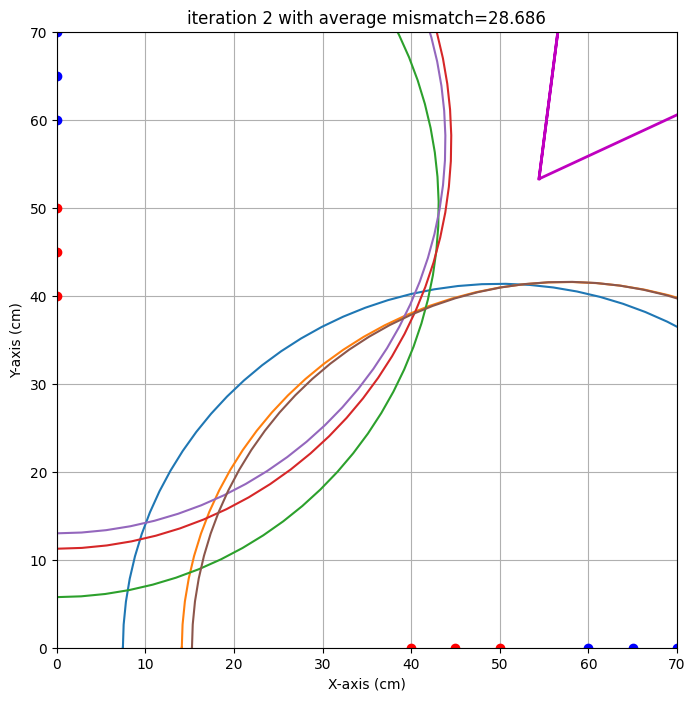

end iteration 2 with average mismatch=28.686


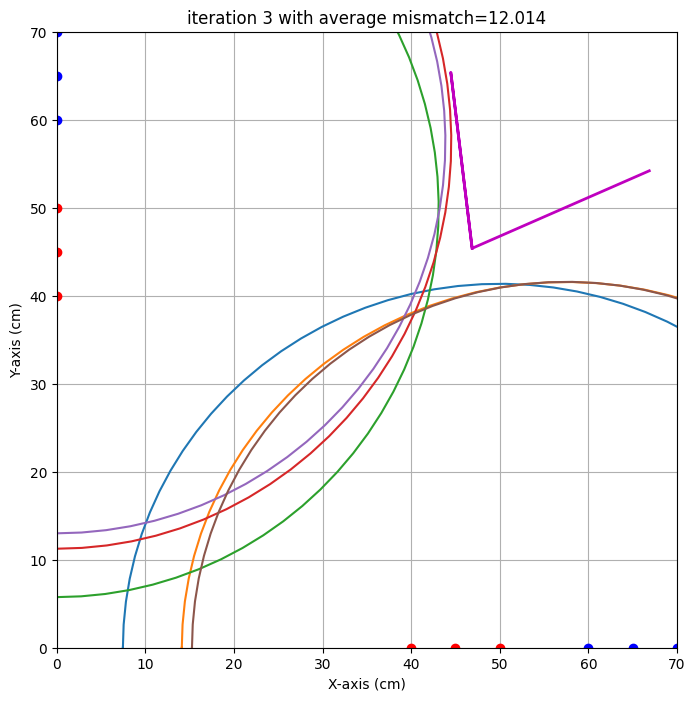

end iteration 3 with average mismatch=12.014


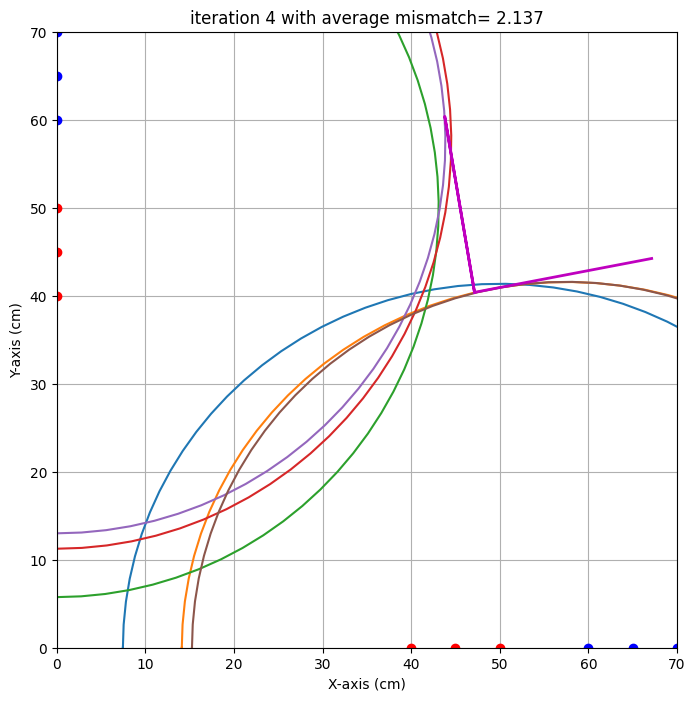

end iteration 4 with average mismatch= 2.137


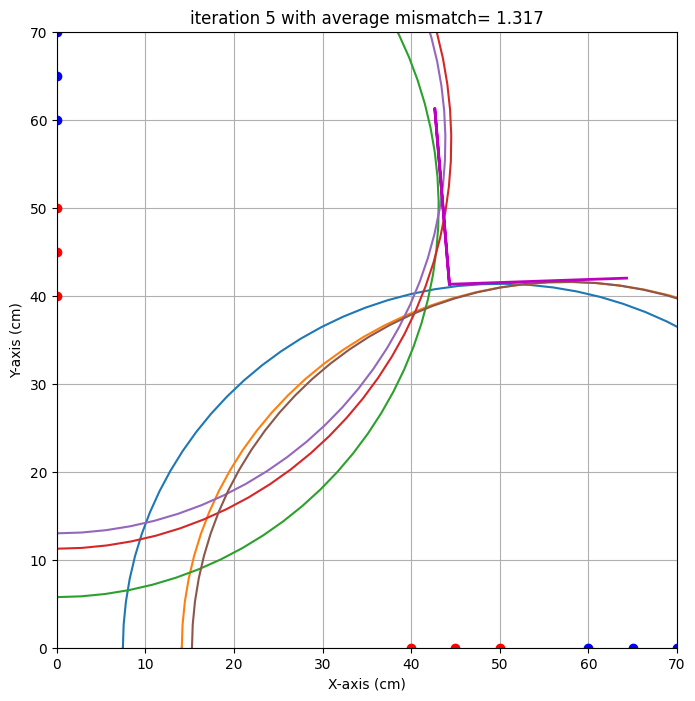

end iteration 5 with average mismatch= 1.317


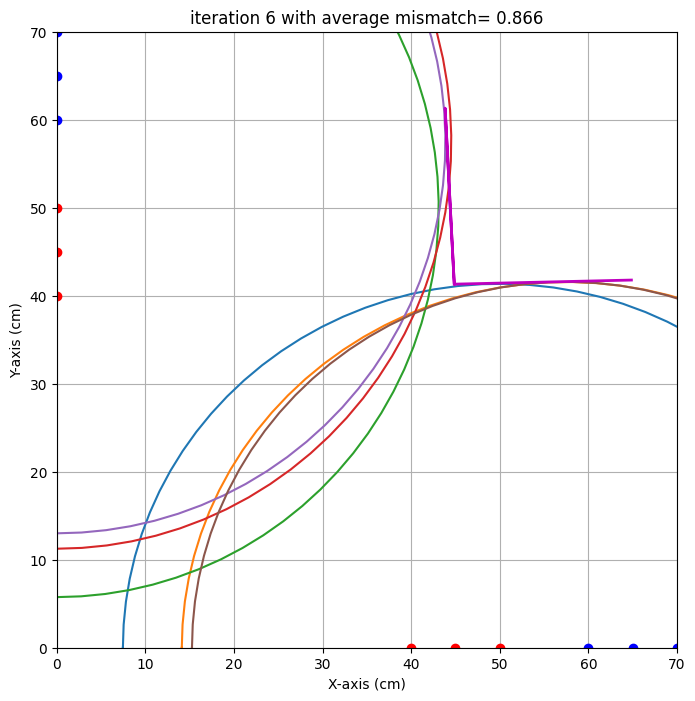

end iteration 6 with average mismatch= 0.866
end iteration 7 with average mismatch= 0.855
end iteration 8 with average mismatch= 0.854
end iteration 9 with average mismatch= 0.854
end iteration 10 with average mismatch= 0.854
end iteration 11 with average mismatch= 0.854
end iteration 12 with average mismatch= 0.854
end iteration 13 with average mismatch= 0.847


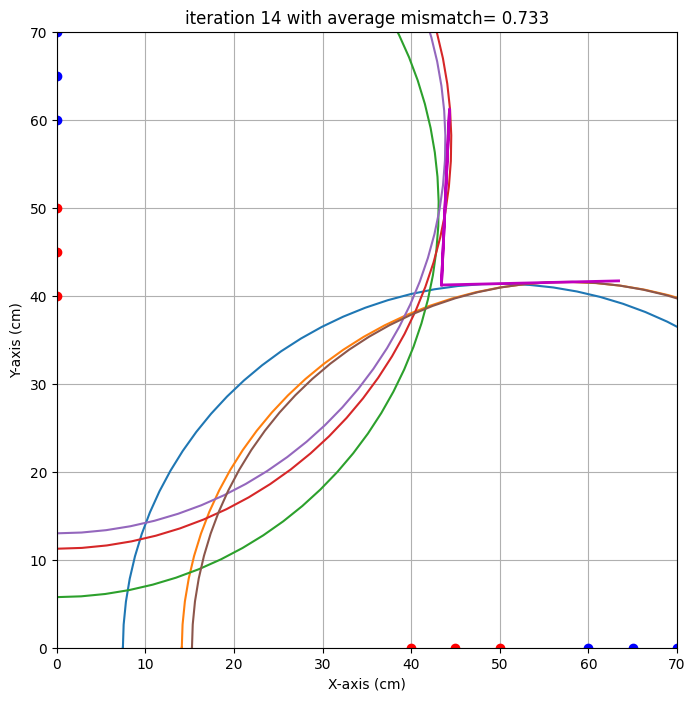

end iteration 14 with average mismatch= 0.733


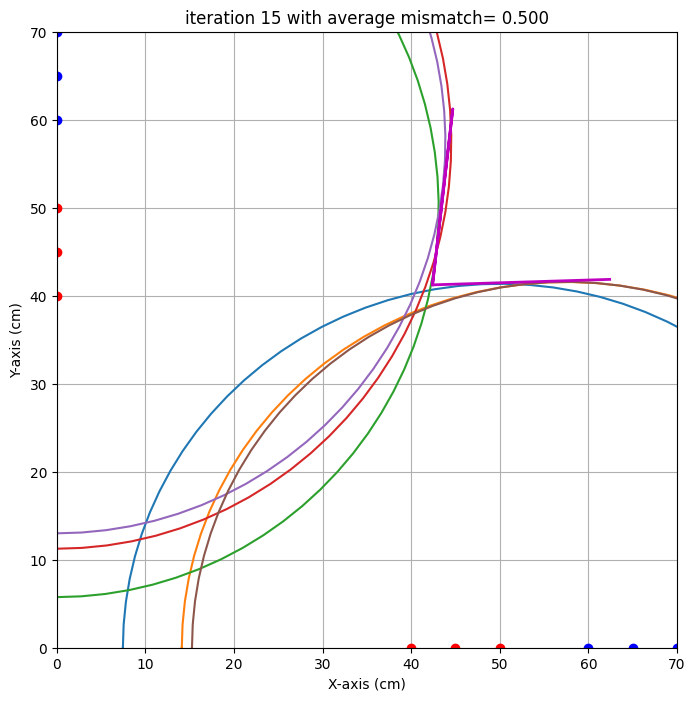

end iteration 15 with average mismatch= 0.500
end iteration 16 with average mismatch= 0.490


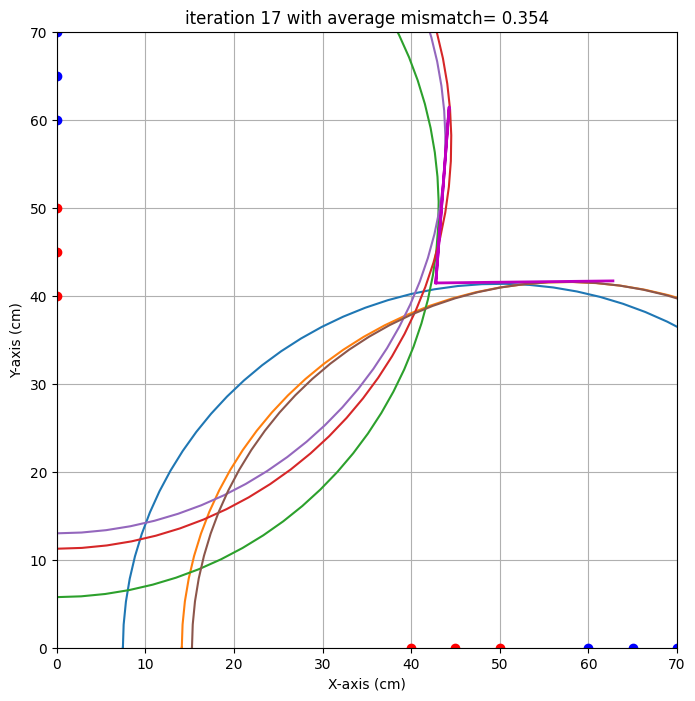

end iteration 17 with average mismatch= 0.354
end iteration 18 with average mismatch= 0.351
end iteration 19 with average mismatch= 0.351
end iteration 20 with average mismatch= 0.351
end iteration 21 with average mismatch= 0.351
end iteration 22 with average mismatch= 0.351
end iteration 23 with average mismatch= 0.351
end iteration 24 with average mismatch= 0.351
end iteration 25 with average mismatch= 0.351
end iteration 26 with average mismatch= 0.351
end iteration 27 with average mismatch= 0.351
end iteration 28 with average mismatch= 0.351
end iteration 29 with average mismatch= 0.351
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.351
###############################################################################
end of iteration  30
Best alpha=   0.67 with uncertainty=   2.93
Best beta =   4.32 with uncertainty=   8.49
Best x0   =  42.77 with uncertain

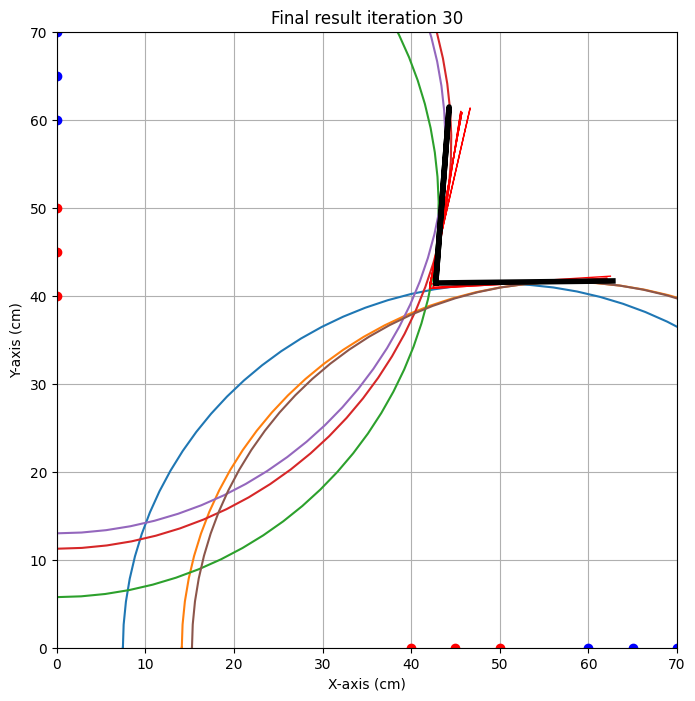

{'alpha': np.float64(0.6701740559960179), 'alpha_eps': np.float64(2.9332175248594616), 'beta': np.float64(4.323198892377162), 'beta_eps': np.float64(8.487796701506207), 'x0': np.float64(42.77207071945841), 'x0_eps': np.float64(0.6930008411970334), 'y0': np.float64(41.44583682171157), 'y0_eps': np.float64(0.6194707591964317)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 42.3 cm met een standaardafwijking van 3.6 cm 
y0 target is : 32.0. Gevonden waarde: 35.2 cm met een standaardafwijking van 1.9 cm 
alpha target is : 10.0. Gevonden waarde: 9.6 graden met een standaardafwijking van 9.6 graad 
beta target is : 10.0. Gevonden waarde: -4.8 graden met een standaardafwijking van 10.9 graad 

locatie 2 
x0 target is : 42.0. Gevonden waarde: 42.8 cm met een standaardafwijking van 0.7 cm 
y0 target is : 38.0. Gevonden waarde: 41.4 cm met een standaardafwijking van 0.6 cm 
alpha target is : 15.0. Gevonden waarde: 0.7 graden met een standaardafwijking van 2.9 graad 
beta target is : 10.0. Gevo

In [40]:
# Voeg hier je meetgegevens van deze iteratie in:
# Dit is iteratie nummer 2

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':38,
                    'y0':32,
                    'alpha' : 10,
                    'beta' : 10,},
           'locatie 2':{'x0':42,
                    'y0':38,
                    'alpha' : 15,
                    'beta' : 10}
             }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, x],
    [40, 0, 50, 0, 71.6],
    [45, 0, 70, 0, 78.3],
    [0, 45, 0, 20, 89.0],
    [0, 45, 0, 70, 85.4],
    [20, 0, 70, 0, 88.4],
    [0, 70, 0, 20, 93.6],
    [0, 25, 0, 45, 86.4],
    #[25, 0, 45, 0, -],
    [0, 50, 0, 65, 83.5],
    [50, 0, 65, 0, 76.0]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, -],
    [40, 0, 60, 0, 85.1],
    [45, 0, 70, 0, 86.8],
    #[0, 45, 0, 20, -],
    [0, 40, 0, 60, 88.5],
    [0, 45, 0, 70, 92.5],
    #[20, 0, 70, 0, -],
    #[0, 70, 0, 20, -],
    #[0, 25, 0 45, -],
    [0, 50, 0, 65, 89.0],
    #[25, 0, 45, 0, -],
    [50, 0, 65, 0, 84.5]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  20   0  57.7
1  70   0  30   0  67.1
2   0  45   0  20  53.3
3  20   0  70   0  72.8
4   0  25   0  45  50.2
5  25   0  45   0  55.8


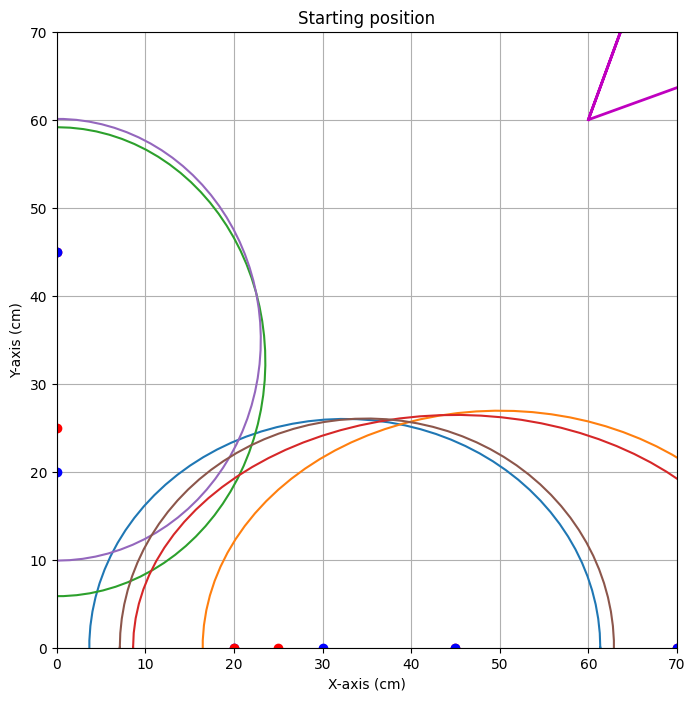


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.881


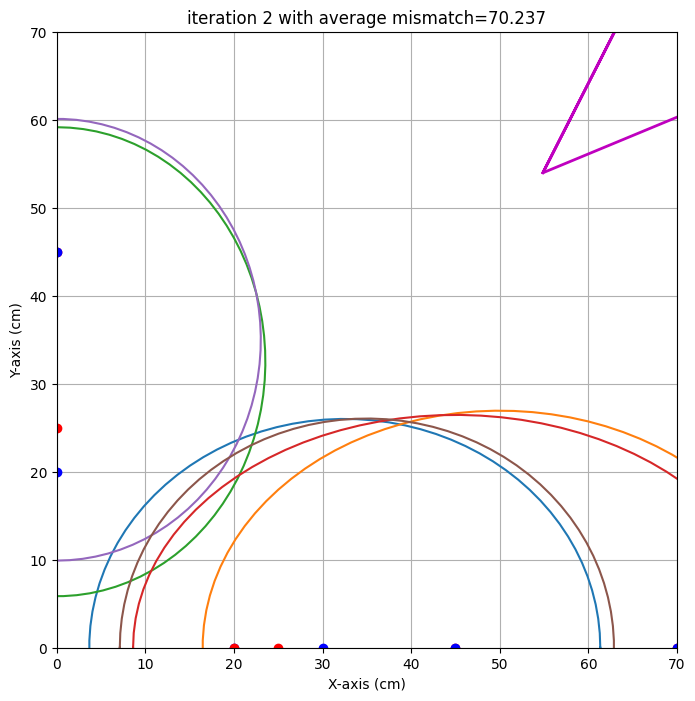

end iteration 2 with average mismatch=70.237


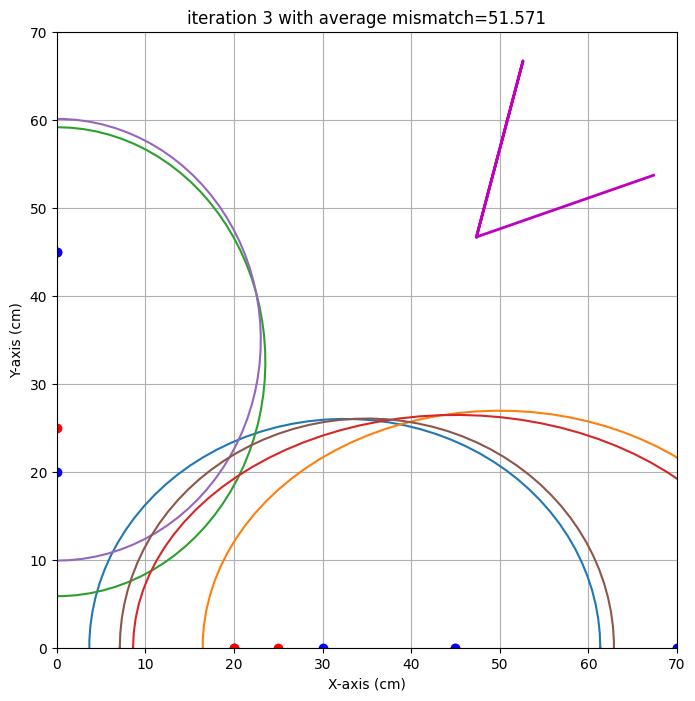

end iteration 3 with average mismatch=51.571


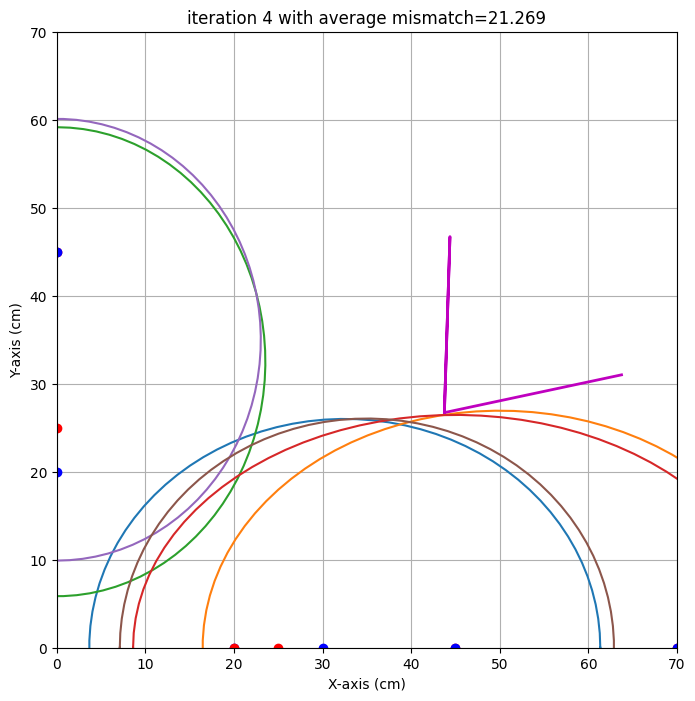

end iteration 4 with average mismatch=21.269


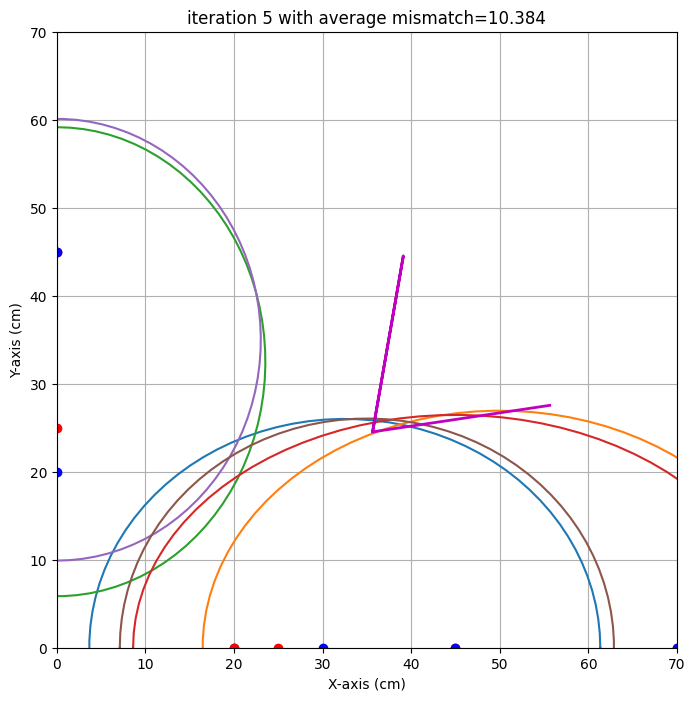

end iteration 5 with average mismatch=10.384


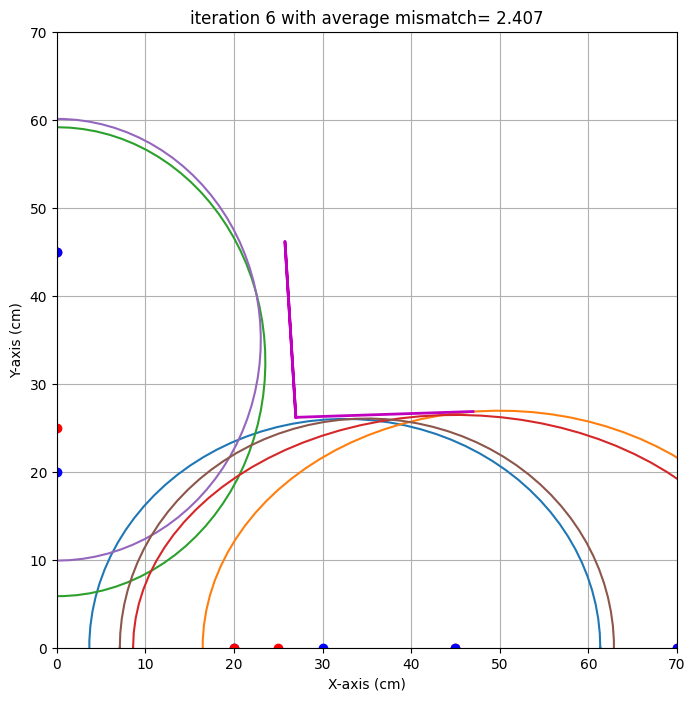

end iteration 6 with average mismatch= 2.407


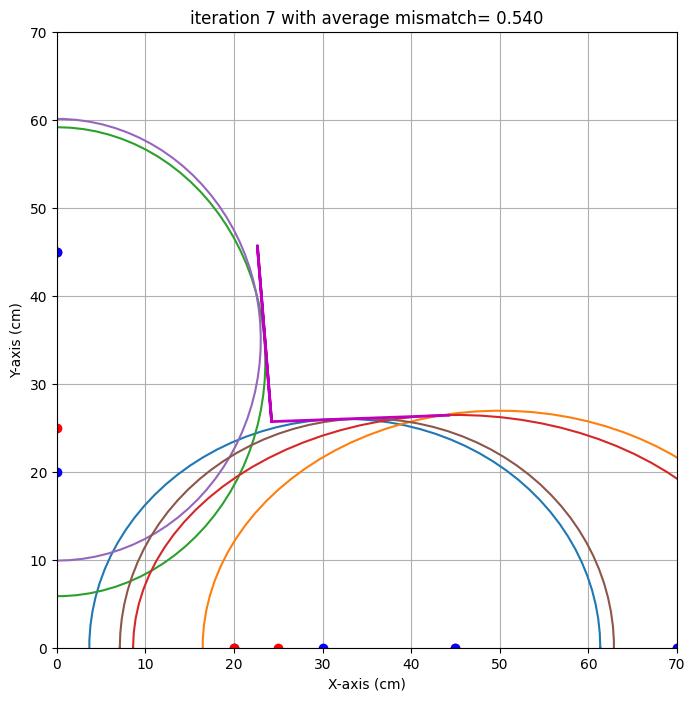

end iteration 7 with average mismatch= 0.540


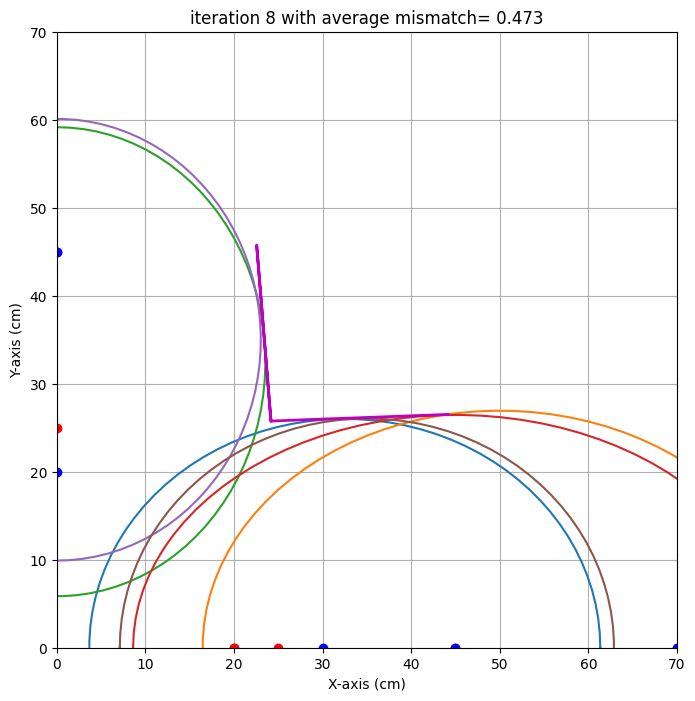

end iteration 8 with average mismatch= 0.473
end iteration 9 with average mismatch= 0.468
end iteration 10 with average mismatch= 0.461
end iteration 11 with average mismatch= 0.460
end iteration 12 with average mismatch= 0.460
end iteration 13 with average mismatch= 0.460
end iteration 14 with average mismatch= 0.460
end iteration 15 with average mismatch= 0.426
end iteration 16 with average mismatch= 0.396
end iteration 17 with average mismatch= 0.396
end iteration 18 with average mismatch= 0.396
end iteration 19 with average mismatch= 0.396
end iteration 20 with average mismatch= 0.396
end iteration 21 with average mismatch= 0.396
end iteration 22 with average mismatch= 0.396
end iteration 23 with average mismatch= 0.395
end iteration 24 with average mismatch= 0.367
end iteration 25 with average mismatch= 0.348
end iteration 26 with average mismatch= 0.321
end iteration 27 with average mismatch= 0.318
end iteration 28 with average mismatch= 0.318
end iteration 29 with average mismat

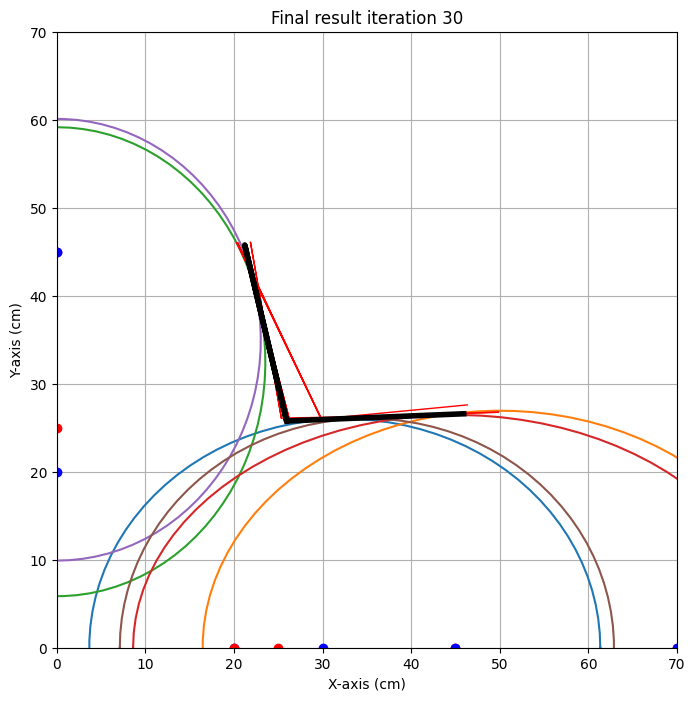

{'alpha': np.float64(2.3375445050077412), 'alpha_eps': np.float64(3.184693169886619), 'beta': np.float64(-13.29985054180543), 'beta_eps': np.float64(12.176686453529552), 'x0': np.float64(25.935511071699263), 'x0_eps': np.float64(3.9094008488334957), 'y0': np.float64(25.76731095898818), 'y0_eps': np.float64(0.3349274599767682)}
test locatie 
x0 target is : 26.0. Gevonden waarde: 25.9 cm met een standaardafwijking van 3.9 cm 
y0 target is : 25.0. Gevonden waarde: 25.8 cm met een standaardafwijking van 0.3 cm 
alpha target is : 1.0. Gevonden waarde: 2.3 graden met een standaardafwijking van 3.2 graad 
beta target is : -13.0. Gevonden waarde: -13.3 graden met een standaardafwijking van 12.2 graad 



In [41]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  26,
                    'y0':  25,
                    'alpha' : 1,
                    'beta' : -13
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [45, 0, 20, 0, 57.7],
                    #[45, 0, 70, 0, -],
                    [70, 0, 30, 0, 67.1],
                    [0, 45, 0, 20, 53.3],
                    #[0, 45, 0, 70, -],
                    #[0, 70, 0, 30, -]
                    [20, 0, 70, 0, 72.8],
                    #[0, 70, 0, 20, -]
                    [0, 25, 0, 45, 50.2],
                    #,
                    #[0, 50, 0, 65, -],
                    [25, 0, 45, 0, 55.8],
                    #[50, 0, 65, 0, -]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

## Iteratie 0: onze individuele blokschema's (13:40)
Figuur: ![Alt](Iteratie0Frank.jpeg "Iteratie 0 van Frank")

Figuur: ![Alt](iteratie0Kimi.jpeg "Iteratie 0 van Kimi")

Bij onze individuele iteraties hebben we allebei gebruikgemaakt van een methode om eerst te kaderen waar het punt van het scherm ongeveer zit. Vervolgens voeren we meerdere metingen uit op basis van de verwachte plek van het scherm. Bij Frank is het veld verdeeld in kwadranten, en bij Kimi in octanten.

Bij Frank was het probleem dat de er te weinig ellipsen gemeten werden om een accurate resolutie te verkrijgen, waardoor het enkel zichtbaar werd in welk kwadrant het flapje zich bevond, zonder dat er bepaald werd waar de hoek zich bevond.

Bij Kimi bleek dat de manier van lokalisatie in de octanten niet helemaal werkte. Ook klopte de metingcombinaties per octant niet, want daar werd niet rekening gehouden met kleine hoeken.

## Iteratie 1: gecombineerd blokschema (14:20)

Figuur: ![Alt](Iteratie1.jpeg "gezamenlijk blokschema")

Het bleek dat het lokaliseren in octanten/kwadranten niet de beste aanpak was, vooral niet wanneer de hoek ook moet kunnen fluctueren. We hebben daarom voor iteratie 1 een hele andere aanpak gebruikt. We starten de meting op een bepaald punt, en als deze geen bruikbare waarde geeft, dan weten we iets over de positie dan verschuiven we de zender/ontvanger naar een andere plek. Dit doen we voor zowel de x als y kant.


## Iteratie 2: verbeterd met meer metingen (15:00)

Figuur: ![Alt](iteratie2.jpeg "gezamenlijk blokschema")

De metingen bleken niet heel goed uit te komen met het vorige algoritme, maar de werking was er wel. Daarom hebben we voor de laatste iteratie wat meer meetpunten toegevoegd, waar de zender en ontvanger ook dichterbij elkaar liggen. Dan kan de hoek beter bepaald worden.
